In [1]:
# 导入库
import json
from pathlib import Path

import numpy as np
import pandas as pd

In [2]:
# 读取 JSON 文件
data_path = Path("A_data.json")

with open(data_path, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

print(f"数据类型: {type(raw_data)}")
print(f"样本数量: {len(raw_data)}")

数据类型: <class 'list'>
样本数量: 251


In [3]:
# 看第一条样本长什么样
first_sample = raw_data[0]

print("第一条记录的顶层字段：")
print(first_sample.keys())

第一条记录的顶层字段：
dict_keys(['GUID', 'conductivity', 'temperature', 'RUN_ID', 'RUN_TYPE', 'timestamp', 'pH', 'electrolyte', 'electrochemistry'])


In [4]:
# 查看第一条样本的关键信息
print("GUID:", first_sample.get("GUID"))
print("conductivity:", first_sample.get("conductivity"))
print("pH:", first_sample.get("pH"))
print("temperature:", first_sample.get("temperature"))
print("RUN_ID:", first_sample.get("RUN_ID"))
print("RUN_TYPE:", first_sample.get("RUN_TYPE"))
print("timestamp:", first_sample.get("timestamp"))

GUID: {CB4B9CC2-CDBD-FE26-E788-729AF26C8A85}
conductivity: 111.2
pH: 8.55
temperature: 21.9
RUN_ID: AML07142019eimnsd
RUN_TYPE: production
timestamp: 7/14/2019,4:25:04 PM


In [5]:
# 检查嵌套字段结构
print("electrolyte 字段：")
print(first_sample["electrolyte"].keys())

print("\nelectrolyte -> volumes:")
print(first_sample["electrolyte"]["volumes"])

print("\nelectrolyte -> source molalities:")
print(first_sample["electrolyte"]["source molalities"])

print("\nelectrolyte -> source densities:")
print(first_sample["electrolyte"]["source densities"])

electrolyte 字段：
dict_keys(['volumes', 'source molalities', 'source densities'])

electrolyte -> volumes:
{'water': 0.3, 'Na2SO4': 2.2, 'LiNO3': 0.5, 'Li2SO4': 2.6, 'NaNO3': 0.3, 'NaClO4': 1.1}

electrolyte -> source molalities:
{'water': 0.0, 'Na2SO4': 1.5, 'LiNO3': 7.02, 'Li2SO4': 3.01, 'NaNO3': 10.03, 'NaClO4': 16.03}

electrolyte -> source densities:
{'water': 1.0, 'Na2SO4': 1.16, 'LiNO3': 1.21, 'Li2SO4': 1.22, 'NaNO3': 1.37, 'NaClO4': 1.66}


In [6]:
# 检查电化学数据结构
print("electrochemistry 字段：")
print(first_sample["electrochemistry"].keys())

ec = first_sample["electrochemistry"]

print("\n数组长度检查：")
print("len(i) =", len(ec["i"]))
print("len(V) =", len(ec["V"]))
print("len(t) =", len(ec["t"]))

print("\nderived_quantities:")
print(ec.get("derived_quantities", {}))

electrochemistry 字段：
dict_keys(['i', 'V', 't', 'test_name', 'derived_quantities'])

数组长度检查：
len(i) = 601
len(V) = 601
len(t) = 601

derived_quantities:
{'TAFEL CATHODE V': 1.670057, 'TAFEL ANODE V': -0.938493, '1mA/cm^2 CATHODE V': 1.568029, '1mA/cm^2 ANODE V': -0.868941}


In [7]:
# 做一个最基础的数据质量检查
bad_samples = []

for idx, sample in enumerate(raw_data):
    try:
        ec = sample["electrochemistry"]
        if not (len(ec["i"]) == len(ec["V"]) == len(ec["t"])):
            bad_samples.append((idx, sample.get("GUID"), "电化学数组长度不一致"))
    except Exception as e:
        bad_samples.append((idx, sample.get("GUID"), str(e)))

print(f"异常样本数: {len(bad_samples)}")
bad_samples[:10]

异常样本数: 0


[]

In [8]:
# 先整理出一个“基础表”
base_rows = []

for sample in raw_data:
    row = {
        "GUID": sample.get("GUID"),
        "conductivity": sample.get("conductivity"),
        "pH": sample.get("pH"),
        "temperature": sample.get("temperature"),
        "RUN_ID": sample.get("RUN_ID"),
        "RUN_TYPE": sample.get("RUN_TYPE"),
        "timestamp": sample.get("timestamp"),
        "test_name": sample.get("electrochemistry", {}).get("test_name"),
    }
    base_rows.append(row)

df_base = pd.DataFrame(base_rows)

print(df_base.shape)
df_base.head()

(251, 8)


,GUID,conductivity,pH,temperature,RUN_ID,RUN_TYPE,timestamp,test_name
0,{CB4B9CC2-CDBD-FE26-E788-729AF26C8A85},111.2,8.55,21.9,AML07142019eimnsd,production,"7/14/2019,4:25:04 PM",fast_assessment
1,{7DFFCEA2-855C-552A-86D9-3CDC8692397E},109.6,8.25,21.6,AML07142019eimnsd,production,"7/14/2019,4:47:18 PM",fast_assessment
2,{761311EE-41DC-23D6-EDDE-B747CB1CC15D},85.9,8.80,21.8,AML07142019eimnsd,production,"7/14/2019,5:08:40 PM",fast_assessment
3,{24BDD1EA-13A7-6CEA-5F04-66F921E7C42B},162.9,8.18,21.5,AML07142019eimnsd,production,"7/14/2019,5:30:54 PM",fast_assessment
4,{6B671ED6-759C-9001-1DC4-FC23A8271BD6},156.5,8.29,21.3,AML07142019eimnsd,production,"7/14/2019,6:17:23 PM",fast_assessment


In [9]:
# 看缺失值情况
df_base.isnull().sum()

GUID            0
conductivity    0
pH              0
temperature     0
RUN_ID          0
RUN_TYPE        0
timestamp       0
test_name       0
dtype: int64

In [10]:
# 看基础统计量
df_base.describe(include="all")

,GUID,conductivity,pH,temperature,RUN_ID,RUN_TYPE,timestamp,test_name
count,251,251.000000,251.000000,251.000000,251,251,251,251
unique,251,NaN,NaN,NaN,21,1,251,1
top,{CB4B9CC2-CDBD-FE26-E788-729AF26C8A85},NaN,NaN,NaN,A08092019ythtqw,production,"7/14/2019,4:25:04 PM",fast_assessment
freq,1,NaN,NaN,NaN,35,251,1,251
mean,NaN,133.306215,7.690677,22.163347,NaN,NaN,NaN,NaN
std,NaN,33.866618,1.041018,0.734310,NaN,NaN,NaN,NaN
min,NaN,11.320000,5.210000,20.400000,NaN,NaN,NaN,NaN
25%,NaN,115.250000,6.655000,21.800000,NaN,NaN,NaN,NaN
50%,NaN,142.400000,8.210000,22.100000,NaN,NaN,NaN,NaN
75%,NaN,155.750000,8.470000,22.600000,NaN,NaN,NaN,NaN


In [11]:
# 把 electrolyte 里的 volumes / molality / density 展开成建模表格
# 人话：把“乱七八糟的JSON配方”变成“可以建模的表格特征”

In [12]:
# 先确认有哪些组分名
all_volume_keys = set()
all_molality_keys = set()
all_density_keys = set()

for sample in raw_data:
    elec = sample.get("electrolyte", {})
    all_volume_keys.update(elec.get("volumes", {}).keys())
    all_molality_keys.update(elec.get("source molalities", {}).keys())
    all_density_keys.update(elec.get("source densities", {}).keys())

print("volumes keys:", sorted(all_volume_keys))
print("molality keys:", sorted(all_molality_keys))
print("density keys:", sorted(all_density_keys))

volumes keys: ['Li2SO4', 'LiClO4', 'LiNO3', 'Na2SO4', 'NaBr', 'NaClO4', 'NaNO3', 'water']
molality keys: ['Li2SO4', 'LiClO4', 'LiNO3', 'Na2SO4', 'NaBr', 'NaClO4', 'NaNO3', 'water']
density keys: ['Li2SO4', 'LiClO4', 'LiNO3', 'Na2SO4', 'NaBr', 'NaClO4', 'NaNO3', 'water']


In [13]:
# 定义一个样本展开函数 把嵌套 JSON 里的配方字段拉平成一行
def flatten_sample(sample):
    row = {
        "GUID": sample.get("GUID"),
        "conductivity": sample.get("conductivity"),
        "pH": sample.get("pH"),
        "temperature": sample.get("temperature"),
        "RUN_ID": sample.get("RUN_ID"),
        "RUN_TYPE": sample.get("RUN_TYPE"),
        "timestamp": sample.get("timestamp"),
        "test_name": sample.get("electrochemistry", {}).get("test_name"),
    }
    
    electrolyte = sample.get("electrolyte", {})
    
    volumes = electrolyte.get("volumes", {})
    molalities = electrolyte.get("source molalities", {})
    densities = electrolyte.get("source densities", {})
    
    for k, v in volumes.items():
        row[f"vol_{k}"] = v
        
    for k, v in molalities.items():
        row[f"molality_{k}"] = v
        
    for k, v in densities.items():
        row[f"density_{k}"] = v
    
    return row

In [14]:
# 展开全部样本
rows = [flatten_sample(sample) for sample in raw_data]
df_formula = pd.DataFrame(rows)

print(df_formula.shape)
df_formula.head()

(251, 32)


,GUID,conductivity,pH,temperature,RUN_ID,RUN_TYPE,timestamp,test_name,vol_water,vol_Na2SO4,...,density_LiNO3,density_Li2SO4,density_NaNO3,density_NaClO4,vol_NaBr,molality_NaBr,density_NaBr,vol_LiClO4,molality_LiClO4,density_LiClO4
0,{CB4B9CC2-CDBD-FE26-E788-729AF26C8A85},111.2,8.55,21.9,AML07142019eimnsd,production,"7/14/2019,4:25:04 PM",fast_assessment,0.3,2.2,...,1.21,1.22,1.37,1.66,NaN,NaN,NaN,NaN,NaN,NaN
1,{7DFFCEA2-855C-552A-86D9-3CDC8692397E},109.6,8.25,21.6,AML07142019eimnsd,production,"7/14/2019,4:47:18 PM",fast_assessment,0.0,1.1,...,1.21,1.22,1.37,1.66,NaN,NaN,NaN,NaN,NaN,NaN
2,{761311EE-41DC-23D6-EDDE-B747CB1CC15D},85.9,8.80,21.8,AML07142019eimnsd,production,"7/14/2019,5:08:40 PM",fast_assessment,2.9,0.0,...,1.21,1.22,1.37,1.66,NaN,NaN,NaN,NaN,NaN,NaN
3,{24BDD1EA-13A7-6CEA-5F04-66F921E7C42B},162.9,8.18,21.5,AML07142019eimnsd,production,"7/14/2019,5:30:54 PM",fast_assessment,0.4,0.3,...,1.21,1.22,1.37,1.66,NaN,NaN,NaN,NaN,NaN,NaN
4,{6B671ED6-759C-9001-1DC4-FC23A8271BD6},156.5,8.29,21.3,AML07142019eimnsd,production,"7/14/2019,6:17:23 PM",fast_assessment,2.2,0.0,...,1.21,1.22,1.37,1.66,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# 检查是否有缺失列
df_formula.isnull().sum().sort_values(ascending=False).head(30)

molality_LiClO4    180
density_LiClO4     180
molality_NaBr      180
vol_NaBr           180
vol_LiClO4         180
density_NaBr       180
molality_Na2SO4    148
vol_Na2SO4         148
density_Na2SO4     148
molality_LiNO3     117
vol_LiNO3          117
vol_Li2SO4         117
density_LiNO3      117
density_Li2SO4     117
molality_Li2SO4    117
vol_NaNO3          109
density_NaNO3      109
molality_NaClO4    109
vol_NaClO4         109
molality_NaNO3     109
density_NaClO4     109
vol_water            0
molality_water       0
test_name            0
conductivity         0
GUID                 0
pH                   0
temperature          0
RUN_ID               0
RUN_TYPE             0
dtype: int64

In [16]:
# 把配方相关缺失值补成 0
formula_cols = [c for c in df_formula.columns if c.startswith("vol_") or c.startswith("molality_") or c.startswith("density_")]

df_formula[formula_cols] = df_formula[formula_cols].fillna(0)

df_formula[formula_cols].isnull().sum().sum()

np.int64(0)

In [17]:
# 检查体积特征
volume_cols = [c for c in df_formula.columns if c.startswith("vol_")]

df_formula["total_volume"] = df_formula[volume_cols].sum(axis=1)

df_formula[["total_volume"] + volume_cols].head()


,total_volume,vol_water,vol_Na2SO4,vol_LiNO3,vol_Li2SO4,vol_NaNO3,vol_NaClO4,vol_NaBr,vol_LiClO4
0,7.0,0.3,2.2,0.5,2.6,0.3,1.1,0.0,0.0
1,7.0,0.0,1.1,1.1,3.2,0.6,1.0,0.0,0.0
2,7.0,2.9,0.0,0.6,3.3,0.1,0.1,0.0,0.0
3,7.0,0.4,0.3,1.3,0.1,4.6,0.3,0.0,0.0
4,7.0,2.2,0.0,1.7,0.1,0.9,2.1,0.0,0.0


In [18]:
# 看总体积分布
df_formula["total_volume"].describe()

count    2.510000e+02
mean     7.000000e+00
std      2.972414e-16
min      7.000000e+00
25%      7.000000e+00
50%      7.000000e+00
75%      7.000000e+00
max      7.000000e+00
Name: total_volume, dtype: float64

In [19]:
# 构造体积分数特征
for col in volume_cols:
    frac_col = col.replace("vol_", "frac_")
    df_formula[frac_col] = np.where(
        df_formula["total_volume"] > 0,
        df_formula[col] / df_formula["total_volume"],
        0
    )

frac_cols = [c for c in df_formula.columns if c.startswith("frac_")]
df_formula[frac_cols].head()

,frac_water,frac_Na2SO4,frac_LiNO3,frac_Li2SO4,frac_NaNO3,frac_NaClO4,frac_NaBr,frac_LiClO4
0,0.042857,0.314286,0.071429,0.371429,0.042857,0.157143,0.0,0.0
1,0.000000,0.157143,0.157143,0.457143,0.085714,0.142857,0.0,0.0
2,0.414286,0.000000,0.085714,0.471429,0.014286,0.014286,0.0,0.0
3,0.057143,0.042857,0.185714,0.014286,0.657143,0.042857,0.0,0.0
4,0.314286,0.000000,0.242857,0.014286,0.128571,0.300000,0.0,0.0


In [20]:
# 检查体积分数是否加和为 1
df_formula["frac_sum"] = df_formula[frac_cols].sum(axis=1)
df_formula["frac_sum"].describe()

count    2.510000e+02
mean     1.000000e+00
std      4.915167e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: frac_sum, dtype: float64

In [21]:
# 构造几个简单但有用的派生特征

# 非水组分总体积
non_water_volume_cols = [c for c in volume_cols if c != "vol_water"]
df_formula["non_water_total_volume"] = df_formula[non_water_volume_cols].sum(axis=1)

# 盐的数量（体积 > 0 的组分数，不算水）
df_formula["num_active_solutes"] = (df_formula[non_water_volume_cols] > 0).sum(axis=1)

# 水含量占比
if "vol_water" in df_formula.columns:
    df_formula["water_fraction"] = np.where(
        df_formula["total_volume"] > 0,
        df_formula["vol_water"] / df_formula["total_volume"],
        0
    )
else:
    df_formula["water_fraction"] = 0

df_formula[["total_volume", "non_water_total_volume", "num_active_solutes", "water_fraction"]].head()

,total_volume,non_water_total_volume,num_active_solutes,water_fraction
0,7.0,6.7,5,0.042857
1,7.0,7.0,5,0.000000
2,7.0,4.1,4,0.414286
3,7.0,6.6,5,0.057143
4,7.0,4.8,4,0.314286


In [22]:
# 先筛出一个“基础建模表”
target_cols = ["conductivity", "pH"]
meta_cols = ["GUID", "RUN_ID", "RUN_TYPE", "timestamp", "test_name"]
basic_feature_cols = volume_cols + frac_cols + ["total_volume", "non_water_total_volume", "num_active_solutes", "water_fraction"]

df_model_base = df_formula[meta_cols + target_cols + basic_feature_cols].copy()

print(df_model_base.shape)
df_model_base.head()

(251, 27)


,GUID,RUN_ID,RUN_TYPE,timestamp,test_name,conductivity,pH,vol_water,vol_Na2SO4,vol_LiNO3,...,frac_LiNO3,frac_Li2SO4,frac_NaNO3,frac_NaClO4,frac_NaBr,frac_LiClO4,total_volume,non_water_total_volume,num_active_solutes,water_fraction
0,{CB4B9CC2-CDBD-FE26-E788-729AF26C8A85},AML07142019eimnsd,production,"7/14/2019,4:25:04 PM",fast_assessment,111.2,8.55,0.3,2.2,0.5,...,0.071429,0.371429,0.042857,0.157143,0.0,0.0,7.0,6.7,5,0.042857
1,{7DFFCEA2-855C-552A-86D9-3CDC8692397E},AML07142019eimnsd,production,"7/14/2019,4:47:18 PM",fast_assessment,109.6,8.25,0.0,1.1,1.1,...,0.157143,0.457143,0.085714,0.142857,0.0,0.0,7.0,7.0,5,0.000000
2,{761311EE-41DC-23D6-EDDE-B747CB1CC15D},AML07142019eimnsd,production,"7/14/2019,5:08:40 PM",fast_assessment,85.9,8.80,2.9,0.0,0.6,...,0.085714,0.471429,0.014286,0.014286,0.0,0.0,7.0,4.1,4,0.414286
3,{24BDD1EA-13A7-6CEA-5F04-66F921E7C42B},AML07142019eimnsd,production,"7/14/2019,5:30:54 PM",fast_assessment,162.9,8.18,0.4,0.3,1.3,...,0.185714,0.014286,0.657143,0.042857,0.0,0.0,7.0,6.6,5,0.057143
4,{6B671ED6-759C-9001-1DC4-FC23A8271BD6},AML07142019eimnsd,production,"7/14/2019,6:17:23 PM",fast_assessment,156.5,8.29,2.2,0.0,1.7,...,0.242857,0.014286,0.128571,0.300000,0.0,0.0,7.0,4.8,4,0.314286


In [23]:
# 检查目标变量缺失
df_model_base[target_cols].isnull().sum()

conductivity    0
pH              0
dtype: int64

In [24]:
# 保存一份中间结果
df_model_base.to_csv("model_base_features.csv", index=False, encoding="utf-8-sig")
print("已保存: model_base_features.csv")

已保存: model_base_features.csv


In [25]:
# 第一问
# 把“电化学曲线（i / V / t）”变成“稳定性指标 + 电化学特征”
'''
为刻画电解液的电化学稳定性，本文基于电流-电压-时间曲线数据，提取统计特征及关键电化学参数（如Tafel电位和特定电流密度对应电位），并进一步构造稳定性窗口指标，实现从原始电化学曲线到结构化特征的转换。
曲线统计特征
    I_mean
    I_std
    I_abs_mean
    V_range
动态特征
    dVdt_mean
    dVdt_std
核心电化学指标
    tafel_window
    one_mA_window
'''

'\n为刻画电解液的电化学稳定性，本文基于电流-电压-时间曲线数据，提取统计特征及关键电化学参数（如Tafel电位和特定电流密度对应电位），并进一步构造稳定性窗口指标，实现从原始电化学曲线到结构化特征的转换。\n曲线统计特征\n    I_mean\n    I_std\n    I_abs_mean\n    V_range\n动态特征\n    dVdt_mean\n    dVdt_std\n核心电化学指标\n    tafel_window\n    one_mA_window\n'

In [26]:
# 先写一个单样本特征提取函数
def safe_trapezoid(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    
    if len(y) < 2 or len(x) < 2:
        return np.nan
    
    dx = np.diff(x)
    avg_y = (y[:-1] + y[1:]) / 2
    return np.sum(avg_y * dx)


def extract_echem_features(sample):
    ec = sample.get("electrochemistry", {})
    derived = ec.get("derived_quantities", {})
    
    i_arr = np.array(ec.get("i", []), dtype=float)
    V_arr = np.array(ec.get("V", []), dtype=float)
    t_arr = np.array(ec.get("t", []), dtype=float)
    
    feat = {
        "GUID": sample.get("GUID")
    }
    
    # ---------- 基本合法性 ----------
    if len(i_arr) == 0 or len(V_arr) == 0 or len(t_arr) == 0:
        feat["echem_valid"] = 0
        return feat
    
    if not (len(i_arr) == len(V_arr) == len(t_arr)):
        feat["echem_valid"] = 0
        return feat
    
    feat["echem_valid"] = 1
    feat["n_points"] = len(i_arr)
    
    # ---------- 基础统计 ----------
    feat["V_max"] = np.max(V_arr)
    feat["V_min"] = np.min(V_arr)
    feat["V_range"] = feat["V_max"] - feat["V_min"]
    
    feat["I_max"] = np.max(i_arr)
    feat["I_min"] = np.min(i_arr)
    feat["I_abs_max"] = np.max(np.abs(i_arr))
    feat["I_mean"] = np.mean(i_arr)
    feat["I_abs_mean"] = np.mean(np.abs(i_arr))
    feat["I_std"] = np.std(i_arr)
    
    feat["t_total"] = t_arr[-1] - t_arr[0]
    
    # ---------- 曲线面积 ----------
    feat["area_abs_I_t"] = safe_trapezoid(np.abs(i_arr), t_arr)
    feat["area_I_t"] = safe_trapezoid(i_arr, t_arr)
    
    # ---------- 电压对时间斜率粗特征 ----------
    if len(t_arr) > 1:
        dV_dt = np.diff(V_arr) / np.diff(t_arr)
        feat["dVdt_mean"] = np.mean(dV_dt)
        feat["dVdt_abs_mean"] = np.mean(np.abs(dV_dt))
        feat["dVdt_std"] = np.std(dV_dt)
    else:
        feat["dVdt_mean"] = np.nan
        feat["dVdt_abs_mean"] = np.nan
        feat["dVdt_std"] = np.nan
    
    # ---------- 电流分段统计 ----------
    feat["pos_current_ratio"] = np.mean(i_arr > 0)
    feat["neg_current_ratio"] = np.mean(i_arr < 0)
    feat["zero_current_ratio"] = np.mean(i_arr == 0)
    
    # ---------- 基于 derived_quantities 的关键特征 ----------
    tafel_cathode = derived.get("TAFEL CATHODE V", np.nan)
    tafel_anode = derived.get("TAFEL ANODE V", np.nan)
    cathode_1mA = derived.get("1mA/cm^2 CATHODE V", np.nan)
    anode_1mA = derived.get("1mA/cm^2 ANODE V", np.nan)
    
    feat["TAFEL_CATHODE_V"] = tafel_cathode
    feat["TAFEL_ANODE_V"] = tafel_anode
    feat["ONE_mA_CATHODE_V"] = cathode_1mA
    feat["ONE_mA_ANODE_V"] = anode_1mA
    
    # ---------- 稳定性窗口 ----------
    if pd.notnull(tafel_cathode) and pd.notnull(tafel_anode):
        feat["tafel_window"] = tafel_cathode - tafel_anode
    else:
        feat["tafel_window"] = np.nan
    
    if pd.notnull(cathode_1mA) and pd.notnull(anode_1mA):
        feat["one_mA_window"] = cathode_1mA - anode_1mA
    else:
        feat["one_mA_window"] = np.nan
    
    return feat

In [27]:
# 对全部样本提取电化学特征
echem_rows = [extract_echem_features(sample) for sample in raw_data]
df_echem = pd.DataFrame(echem_rows)

print(df_echem.shape)
df_echem.head()

(251, 27)


,GUID,echem_valid,n_points,V_max,V_min,V_range,I_max,I_min,I_abs_max,I_mean,...,dVdt_std,pos_current_ratio,neg_current_ratio,zero_current_ratio,TAFEL_CATHODE_V,TAFEL_ANODE_V,ONE_mA_CATHODE_V,ONE_mA_ANODE_V,tafel_window,one_mA_window
0,{CB4B9CC2-CDBD-FE26-E788-729AF26C8A85},1,601,1.980906,-1.445513,3.426419,111.111111,-111.111111,111.111111,-2.142725,...,0.969740,0.467554,0.532446,0.0,1.670057,-0.938493,1.568029,-0.868941,2.608550,2.436970
1,{7DFFCEA2-855C-552A-86D9-3CDC8692397E},1,601,2.061609,-1.460748,3.522357,111.111111,-111.111111,111.111111,-2.142725,...,1.005380,0.467554,0.532446,0.0,1.703081,-0.966088,1.595291,-0.893570,2.669169,2.488861
2,{761311EE-41DC-23D6-EDDE-B747CB1CC15D},1,601,1.897312,-1.451685,3.348997,111.111111,-111.111111,111.111111,-2.142725,...,0.980429,0.467554,0.532446,0.0,1.625920,-0.929020,1.528615,-0.788655,2.554940,2.317270
3,{24BDD1EA-13A7-6CEA-5F04-66F921E7C42B},1,601,2.104969,-1.529029,3.633998,111.111111,-111.111111,111.111111,-2.142725,...,1.037324,0.467554,0.532446,0.0,1.748925,-1.017221,1.648280,-0.832859,2.766146,2.481139
4,{6B671ED6-759C-9001-1DC4-FC23A8271BD6},1,601,2.130672,-1.694967,3.825639,111.111111,-111.111111,111.111111,-2.142725,...,1.068299,0.467554,0.532446,0.0,1.754464,-1.011217,1.653924,-0.815276,2.765681,2.469200


In [28]:
# 检查有效样本
df_echem["echem_valid"].value_counts(dropna=False)

echem_valid
1    251
Name: count, dtype: int64

In [29]:
#  看缺失
df_echem.isnull().sum().sort_values(ascending=False)

GUID                  0
echem_valid           0
n_points              0
V_max                 0
V_min                 0
V_range               0
I_max                 0
I_min                 0
I_abs_max             0
I_mean                0
I_abs_mean            0
I_std                 0
t_total               0
area_abs_I_t          0
area_I_t              0
dVdt_mean             0
dVdt_abs_mean         0
dVdt_std              0
pos_current_ratio     0
neg_current_ratio     0
zero_current_ratio    0
TAFEL_CATHODE_V       0
TAFEL_ANODE_V         0
ONE_mA_CATHODE_V      0
ONE_mA_ANODE_V        0
tafel_window          0
one_mA_window         0
dtype: int64

In [30]:
# 看关键特征分布
key_cols = [
    "tafel_window",
    "one_mA_window",
    "V_range",
    "I_abs_mean",
    "area_abs_I_t"
]

df_echem[key_cols].describe()

,tafel_window,one_mA_window,V_range,I_abs_mean,area_abs_I_t
count,251.000000,251.000000,251.000000,2.510000e+02,2.510000e+02
mean,2.513431,2.294681,3.433046,4.523387e+01,2.712950e+03
std,0.387056,0.325120,0.491293,7.119624e-15,4.556559e-13
min,1.624802,1.486424,2.148211,4.523387e+01,2.712950e+03
25%,2.517685,2.136699,3.416106,4.523387e+01,2.712950e+03
50%,2.669972,2.433795,3.624857,4.523387e+01,2.712950e+03
75%,2.730725,2.512874,3.721538,4.523387e+01,2.712950e+03
max,3.031585,2.783795,4.234235,4.523387e+01,2.712950e+03


In [31]:
# 和前面的表合并
df_all = df_model_base.merge(df_echem, on="GUID", how="left")

print(df_all.shape)
df_all.head()

(251, 53)


,GUID,RUN_ID,RUN_TYPE,timestamp,test_name,conductivity,pH,vol_water,vol_Na2SO4,vol_LiNO3,...,dVdt_std,pos_current_ratio,neg_current_ratio,zero_current_ratio,TAFEL_CATHODE_V,TAFEL_ANODE_V,ONE_mA_CATHODE_V,ONE_mA_ANODE_V,tafel_window,one_mA_window
0,{CB4B9CC2-CDBD-FE26-E788-729AF26C8A85},AML07142019eimnsd,production,"7/14/2019,4:25:04 PM",fast_assessment,111.2,8.55,0.3,2.2,0.5,...,0.969740,0.467554,0.532446,0.0,1.670057,-0.938493,1.568029,-0.868941,2.608550,2.436970
1,{7DFFCEA2-855C-552A-86D9-3CDC8692397E},AML07142019eimnsd,production,"7/14/2019,4:47:18 PM",fast_assessment,109.6,8.25,0.0,1.1,1.1,...,1.005380,0.467554,0.532446,0.0,1.703081,-0.966088,1.595291,-0.893570,2.669169,2.488861
2,{761311EE-41DC-23D6-EDDE-B747CB1CC15D},AML07142019eimnsd,production,"7/14/2019,5:08:40 PM",fast_assessment,85.9,8.80,2.9,0.0,0.6,...,0.980429,0.467554,0.532446,0.0,1.625920,-0.929020,1.528615,-0.788655,2.554940,2.317270
3,{24BDD1EA-13A7-6CEA-5F04-66F921E7C42B},AML07142019eimnsd,production,"7/14/2019,5:30:54 PM",fast_assessment,162.9,8.18,0.4,0.3,1.3,...,1.037324,0.467554,0.532446,0.0,1.748925,-1.017221,1.648280,-0.832859,2.766146,2.481139
4,{6B671ED6-759C-9001-1DC4-FC23A8271BD6},AML07142019eimnsd,production,"7/14/2019,6:17:23 PM",fast_assessment,156.5,8.29,2.2,0.0,1.7,...,1.068299,0.467554,0.532446,0.0,1.754464,-1.011217,1.653924,-0.815276,2.765681,2.469200


In [32]:
# 检查关键列是否成功合并
check_cols = [
    "conductivity",
    "pH",
    "tafel_window",
    "one_mA_window",
    "V_range"
]

df_all[check_cols].head()

,conductivity,pH,tafel_window,one_mA_window,V_range
0,111.2,8.55,2.608550,2.436970,3.426419
1,109.6,8.25,2.669169,2.488861,3.522357
2,85.9,8.80,2.554940,2.317270,3.348997
3,162.9,8.18,2.766146,2.481139,3.633998
4,156.5,8.29,2.765681,2.469200,3.825639


In [33]:
# 保存
df_all.to_csv("model_with_echem_features.csv", index=False, encoding="utf-8-sig")

In [34]:
# 综合性能指标构造
'''
把 conductivity + pH + 电化学稳定性
合成一个统一评分：Score
指标            越大越好？
conductivity	✅ 是
tafel_window	✅ 是
one_mA_window	✅ 是
pH偏离度	❌ 越小越好

So 统一方向 + 标准化

人话 算Score 导电率就是傻逼一个
'''

'\n把 conductivity + pH + 电化学稳定性\n合成一个统一评分：Score\n指标            越大越好？\nconductivity\t✅ 是\ntafel_window\t✅ 是\none_mA_window\t✅ 是\npH偏离度\t❌ 越小越好\n\nSo 统一方向 + 标准化\n\n人话 算Score 导电率就是傻逼一个\n'

In [35]:
# PART1     定义目标 pH
pH_target = 7.0

In [36]:
# 构造 pH 偏离度
df_all["pH_deviation"] = np.abs(df_all["pH"] - pH_target)

In [37]:
# PART2 选择用于评分的核心指标
score_features = [
    "conductivity",
    "tafel_window",
    "one_mA_window",
    "pH_deviation"
]

In [38]:
# PART3 标准化
df_score = df_all.copy()

for col in score_features:
    min_val = df_score[col].min()
    max_val = df_score[col].max()
    
    if max_val > min_val:
        df_score[f"{col}_norm"] = (df_score[col] - min_val) / (max_val - min_val)
    else:
        df_score[f"{col}_norm"] = 0

In [39]:
# PART4 方向统一
df_score["pH_score"] = 1 - df_score["pH_deviation_norm"]
df_score["cond_score"] = df_score["conductivity_norm"]
df_score["tafel_score"] = df_score["tafel_window_norm"]
df_score["window_score"] = df_score["one_mA_window_norm"]

In [40]:
# 加权综合评分
# 方法1（主推荐）：均权
df_score["Score_equal"] = (
    df_score["cond_score"] +
    df_score["tafel_score"] +
    df_score["window_score"] +
    df_score["pH_score"]
) / 4

# 方法2（进阶加分）：强调稳定性

w_cond = 0.3
w_tafel = 0.3
w_window = 0.2
w_pH = 0.2

df_score["Score_weighted"] = (
    w_cond * df_score["cond_score"] +
    w_tafel * df_score["tafel_score"] +
    w_window * df_score["window_score"] +
    w_pH * df_score["pH_score"]
)

In [41]:
# PART6 看评分结果
df_score[["Score_equal", "Score_weighted"]].describe()

,Score_equal,Score_weighted
count,251.000000,251.000000
mean,0.616031,0.620817
std,0.130391,0.131128
min,0.270202,0.272399
25%,0.507963,0.501770
50%,0.636730,0.647133
75%,0.711068,0.719780
max,0.854767,0.845502


In [42]:
# 找最优配方
df_score.sort_values("Score_weighted", ascending=False).head(10)

,GUID,RUN_ID,RUN_TYPE,timestamp,test_name,conductivity,pH,vol_water,vol_Na2SO4,vol_LiNO3,...,conductivity_norm,tafel_window_norm,one_mA_window_norm,pH_deviation_norm,pH_score,cond_score,tafel_score,window_score,Score_equal,Score_weighted
139,{EC26DA69-4463-675F-E863-979C9E08C2A5},AML09032019awzhtx,production,"9/3/2019,3:51:45 PM",fast_assessment,150.7,7.04,0.0,1.0,0.0,...,0.740674,0.876208,0.813815,0.011628,0.988372,0.740674,0.876208,0.813815,0.854767,0.845502
173,{CC26D5CD-C0BC-1B09-7171-4A1A9361B4D3},AML09052019ekmtsp,production,"9/5/2019,2:36:29 PM",fast_assessment,119.7,6.50,0.3,0.1,0.0,...,0.575938,0.998872,0.997884,0.189922,0.810078,0.575938,0.998872,0.997884,0.845693,0.834035
164,{38DD30DA-BC59-E86C-E991-EE1AEB42A133},AML09052019ekmtsp,production,"9/5/2019,9:57:35 AM",fast_assessment,148.2,7.17,0.4,0.3,0.0,...,0.727389,0.898207,0.792359,0.062016,0.937984,0.727389,0.898207,0.792359,0.838985,0.833747
170,{6A788641-3118-E177-B468-8DA2C9186A15},AML09052019ekmtsp,production,"9/5/2019,1:20:08 PM",fast_assessment,112.2,6.64,0.0,0.0,0.0,...,0.536082,1.000000,0.982965,0.135659,0.864341,0.536082,1.000000,0.982965,0.845847,0.830286
157,{658EAE98-541B-1F7A-950E-6FE2A77C33E5},AML09042019nanizt,production,"9/4/2019,9:11:16 PM",fast_assessment,162.1,7.15,2.2,0.4,0.0,...,0.801254,0.826366,0.761916,0.054264,0.945736,0.801254,0.826366,0.761916,0.833818,0.829817
46,{C728CD3D-8F64-3AC1-255C-2BDE9394431E},A08082019uigkul,production,"8/8/2019,11:12:33 PM",fast_assessment,170.5,7.54,1.0,0.0,0.0,...,0.845892,0.827032,0.817021,0.205426,0.794574,0.845892,0.827032,0.817021,0.821130,0.824196
48,{A0A3756C-1996-1342-9DE2-C26476ED0DC2},A08082019uigkul,production,"8/8/2019,11:54:38 PM",fast_assessment,165.7,7.62,0.0,0.0,0.0,...,0.820385,0.846422,0.842825,0.236434,0.763566,0.820385,0.846422,0.842825,0.818299,0.821320
55,{B6BBEE56-6A44-E2C5-A640-FE532DF4CF73},A08082019uigkul,production,"8/9/2019,2:18:02 AM",fast_assessment,173.4,6.17,0.0,0.0,0.0,...,0.861303,0.841833,0.867683,0.317829,0.682171,0.861303,0.841833,0.867683,0.813247,0.820911
159,{CB7F26B2-AF22-42B0-998C-2F49B1B96C12},AML09042019nanizt,production,"9/4/2019,10:00:42 PM",fast_assessment,156.6,7.41,1.8,0.6,0.0,...,0.772027,0.846417,0.827644,0.155039,0.844961,0.772027,0.846417,0.827644,0.822762,0.820054
162,{82057D2E-FE98-5629-A6F4-FCD1925EA014},AML09042019nanizt,production,"9/4/2019,11:39:54 PM",fast_assessment,168.0,6.55,0.6,0.1,0.0,...,0.832607,0.858623,0.713585,0.170543,0.829457,0.832607,0.858623,0.713585,0.808568,0.815977


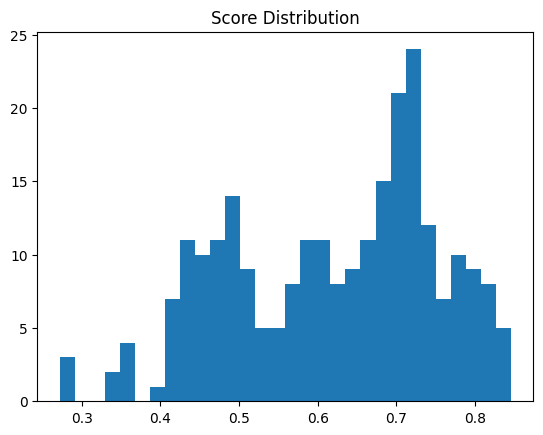

In [43]:
# PART7 可视化
import matplotlib.pyplot as plt

plt.hist(df_score["Score_weighted"], bins=30)
plt.title("Score Distribution")
plt.show()

In [44]:
# 指标分析情况

df_score.sort_values("Score_weighted", ascending=False).head(10)
df_score["Score_weighted"].describe()
df_all[["tafel_window","one_mA_window","area_abs_I_t"]].describe()

,tafel_window,one_mA_window,area_abs_I_t
count,251.000000,251.000000,2.510000e+02
mean,2.513431,2.294681,2.712950e+03
std,0.387056,0.325120,4.556559e-13
min,1.624802,1.486424,2.712950e+03
25%,2.517685,2.136699,2.712950e+03
50%,2.669972,2.433795,2.712950e+03
75%,2.730725,2.512874,2.712950e+03
max,3.031585,2.783795,2.712950e+03


In [45]:
# 第二问
'''
多模型回归对比分析 筛选最佳模型
'''

'\n多模型回归对比分析 筛选最佳模型\n'

In [46]:
# 导入库

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from xgboost import XGBRegressor

In [47]:
# 构造输入特征 X

feature_cols = [
    c for c in df_score.columns
    if (
        c.startswith("vol_")
        or c.startswith("frac_")
        or c.startswith("molality_")
        or c.startswith("density_")
    )
]

extra_formula_cols = [
    "total_volume",
    "non_water_total_volume",
    "num_active_solutes",
    "water_fraction"
]

for c in extra_formula_cols:
    if c in df_score.columns:
        feature_cols.append(c)

feature_cols = sorted(list(set(feature_cols)))

X_all = df_score[feature_cols].copy()

print("特征数:", len(feature_cols))
print("样本数:", X_all.shape[0])
print(feature_cols[:20])

特征数: 20
样本数: 251
['frac_Li2SO4', 'frac_LiClO4', 'frac_LiNO3', 'frac_Na2SO4', 'frac_NaBr', 'frac_NaClO4', 'frac_NaNO3', 'frac_water', 'non_water_total_volume', 'num_active_solutes', 'total_volume', 'vol_Li2SO4', 'vol_LiClO4', 'vol_LiNO3', 'vol_Na2SO4', 'vol_NaBr', 'vol_NaClO4', 'vol_NaNO3', 'vol_water', 'water_fraction']


In [48]:
# 定义预测目标
target_list = ["conductivity", "pH", "Score_weighted"]

target_list += ["tafel_window", "one_mA_window"]

print("预测目标:", target_list)

预测目标: ['conductivity', 'pH', 'Score_weighted', 'tafel_window', 'one_mA_window']


In [49]:
# 定义候选模型
models = {
    "LinearRegression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    
    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    
    "Lasso": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.001))
    ]),
    
    "DecisionTree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeRegressor(
            max_depth=6,
            min_samples_split=4,
            min_samples_leaf=2,
            random_state=42
        ))
    ]),
    
    "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            min_samples_split=4,
            min_samples_leaf=2,
            random_state=42
        ))
    ]),
    
    "ExtraTrees": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesRegressor(
            n_estimators=300,
            max_depth=8,
            min_samples_split=4,
            min_samples_leaf=2,
            random_state=42
        ))
    ]),
    
    "GradientBoosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]),
    
    "AdaBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", AdaBoostRegressor(
            n_estimators=200,
            learning_rate=0.05,
            random_state=42
        ))
    ]),
    
    "KNN": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=5))
    ]),
    
    "SVR": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", SVR(C=10, epsilon=0.05, kernel="rbf"))
    ]),
    
    "XGBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        ))
    ]),
}

In [50]:
# 定义评估函数
def evaluate_regression(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

In [51]:
# 对每个目标分别建模、比较、选最佳模型
all_test_results = []
all_cv_results = []
best_model_summary = {}

saved_predictions = {}   # 保存每个目标最佳模型的预测结果
saved_models = {}        # 保存每个目标最佳模型
saved_splits = {}        # 保存每个目标的数据划分

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for target_col in target_list:
    print(f"\n========== 当前目标: {target_col} ==========")
    
    y_all = df_score[target_col].copy()
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all, test_size=0.2, random_state=42
    )
    
    target_test_results = []
    target_cv_results = []
    
    for model_name, model in models.items():
        # 测试集表现
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        rmse, mae, r2 = evaluate_regression(y_test, y_pred)
        
        target_test_results.append({
            "target": target_col,
            "model": model_name,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2
        })
        
        # 交叉验证表现
        r2_scores = cross_val_score(model, X_all, y_all, cv=kf, scoring="r2")
        rmse_scores = np.sqrt(-cross_val_score(model, X_all, y_all, cv=kf, scoring="neg_mean_squared_error"))
        mae_scores = -cross_val_score(model, X_all, y_all, cv=kf, scoring="neg_mean_absolute_error")
        
        target_cv_results.append({
            "target": target_col,
            "model": model_name,
            "CV_R2_mean": r2_scores.mean(),
            "CV_R2_std": r2_scores.std(),
            "CV_RMSE_mean": rmse_scores.mean(),
            "CV_RMSE_std": rmse_scores.std(),
            "CV_MAE_mean": mae_scores.mean(),
            "CV_MAE_std": mae_scores.std()
        })
    
    df_target_test = pd.DataFrame(target_test_results).sort_values("R2", ascending=False)
    df_target_cv = pd.DataFrame(target_cv_results).sort_values("CV_R2_mean", ascending=False)
    
    all_test_results.append(df_target_test)
    all_cv_results.append(df_target_cv)
    
    # 每个目标的最佳模型：优先看CV_R2_mean
    best_name = df_target_cv.iloc[0]["model"]
    best_model = models[best_name]
    best_model.fit(X_train, y_train)
    best_pred = best_model.predict(X_test)
    
    best_model_summary[target_col] = {
        "best_test_model": df_target_test.iloc[0]["model"],
        "best_test_R2": df_target_test.iloc[0]["R2"],
        "best_cv_model": best_name,
        "best_cv_R2": df_target_cv.iloc[0]["CV_R2_mean"]
    }
    
    saved_predictions[target_col] = pd.DataFrame({
        "y_true": y_test.values,
        "y_pred": best_pred
    })
    
    saved_models[target_col] = best_model
    saved_splits[target_col] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }
    
    print("测试集前5名：")
    print(df_target_test.head())
    print("\n交叉验证前5名：")
    print(df_target_cv.head())


========== 当前目标: conductivity ==========


d:\anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.619e+03, tolerance: 2.184e+01
  model = cd_fast.enet_coordinate_descent(
d:\anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.619e+03, tolerance: 2.184e+01
  model = cd_fast.enet_coordinate_descent(
d:\anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.619e+03, tolerance: 2.400e+01
  model = cd_fast.enet_coo

测试集前5名：
          target         model       RMSE        MAE        R2
3   conductivity  DecisionTree  23.765237  11.885907  0.575030
10  conductivity       XGBoost  26.362649   9.714383  0.477060
4   conductivity  RandomForest  26.824106  11.239932  0.458592
9   conductivity           SVR  27.227521   9.130052  0.442185
8   conductivity           KNN  27.534554  12.252863  0.429534

交叉验证前5名：
          target         model  CV_R2_mean  CV_R2_std  CV_RMSE_mean  \
9   conductivity           SVR    0.718278   0.167089     17.451218   
8   conductivity           KNN    0.701125   0.157237     18.091485   
10  conductivity       XGBoost    0.681505   0.106125     18.836395   
5   conductivity    ExtraTrees    0.677193   0.134088     18.866532   
4   conductivity  RandomForest    0.676259   0.114141     18.957598   

    CV_RMSE_std  CV_MAE_mean  CV_MAE_std  
9      6.883227     7.069533    1.670666  
8      6.305996     9.038365    1.774685  
10     4.336827     8.621350    0.994324  
5    

In [52]:
# 汇总结果，直接看“最佳模型是谁”
df_all_test_results = pd.concat(all_test_results, ignore_index=True)
df_all_cv_results = pd.concat(all_cv_results, ignore_index=True)

df_best_model_summary = pd.DataFrame(best_model_summary).T.reset_index()
df_best_model_summary.columns = ["target", "best_test_model", "best_test_R2", "best_cv_model", "best_cv_R2"]

print("===== 每个目标的最佳模型 =====")
display(df_best_model_summary)

===== 每个目标的最佳模型 =====


,target,best_test_model,best_test_R2,best_cv_model,best_cv_R2
0,conductivity,DecisionTree,0.57503,SVR,0.718278
1,pH,XGBoost,0.937176,ExtraTrees,0.90661
2,Score_weighted,GradientBoosting,0.86507,XGBoost,0.917952
3,tafel_window,XGBoost,0.989294,GradientBoosting,0.990023
4,one_mA_window,XGBoost,0.958531,XGBoost,0.95767


In [53]:
# 找“统一推荐模型”
df_model_rank = df_all_cv_results.copy()

# 对每个目标按 CV_R2_mean 排名，1是最好
df_model_rank["rank_within_target"] = df_model_rank.groupby("target")["CV_R2_mean"].rank(ascending=False, method="min")

df_model_average_rank = (
    df_model_rank.groupby("model")["rank_within_target"]
    .mean()
    .reset_index()
    .sort_values("rank_within_target")
)

print("===== 各模型跨目标平均排名 =====")
display(df_model_average_rank)

===== 各模型跨目标平均排名 =====


,model,rank_within_target
10,XGBoost,1.8
3,GradientBoosting,3.2
7,RandomForest,3.4
2,ExtraTrees,3.4
9,SVR,5.4
1,DecisionTree,6.6
4,KNN,6.6
0,AdaBoost,6.8
8,Ridge,9.0
5,Lasso,9.2


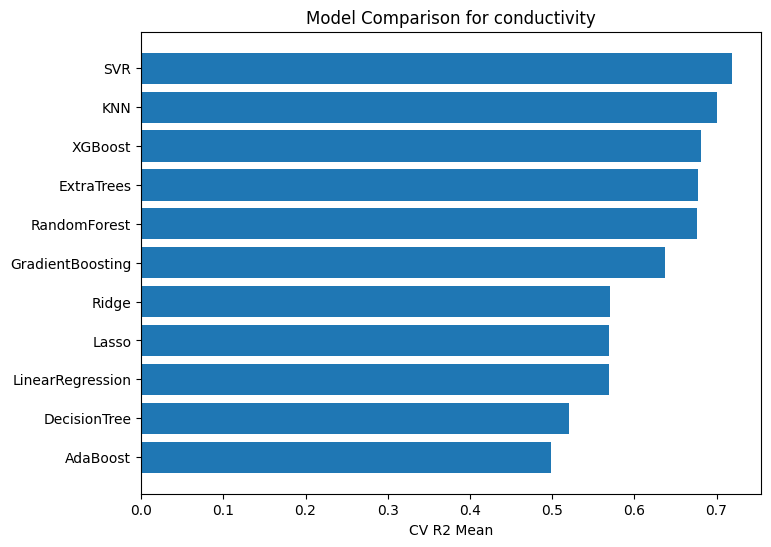

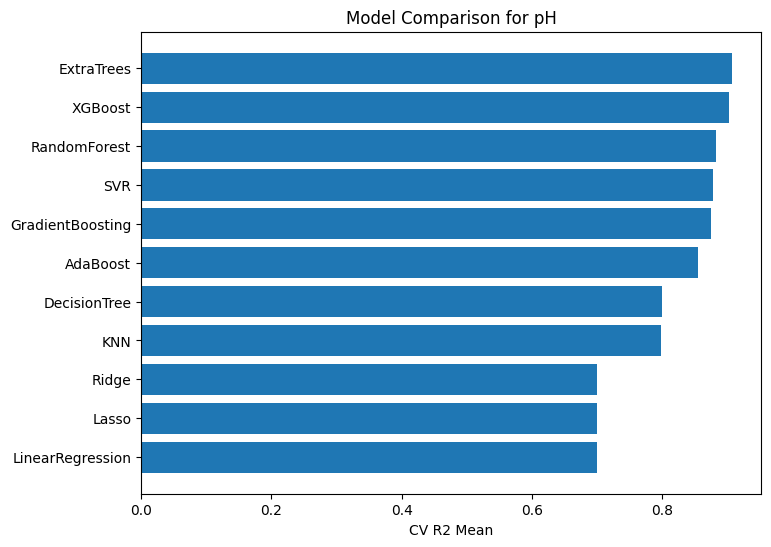

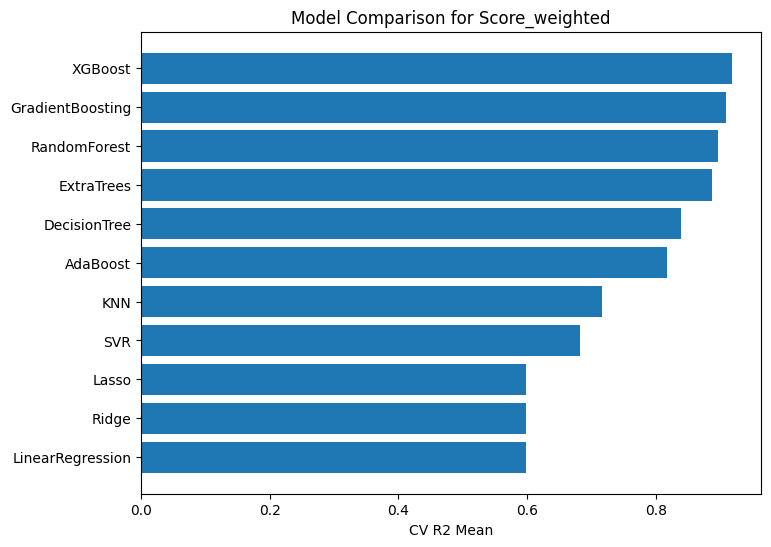

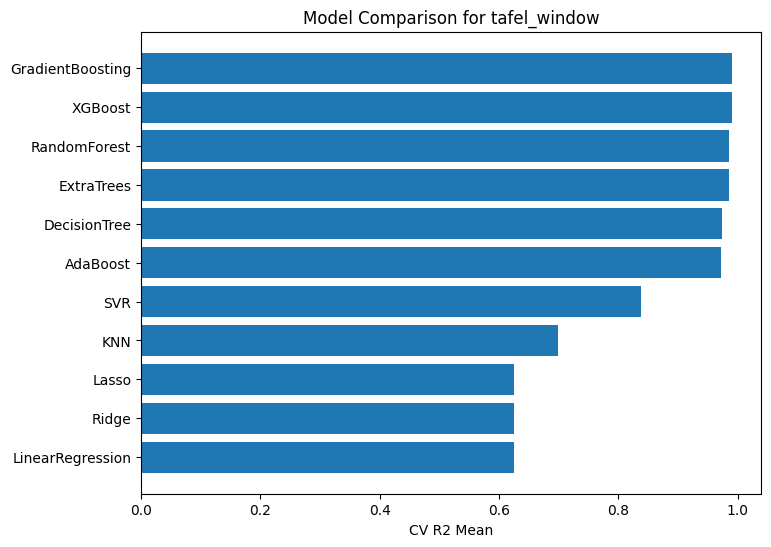

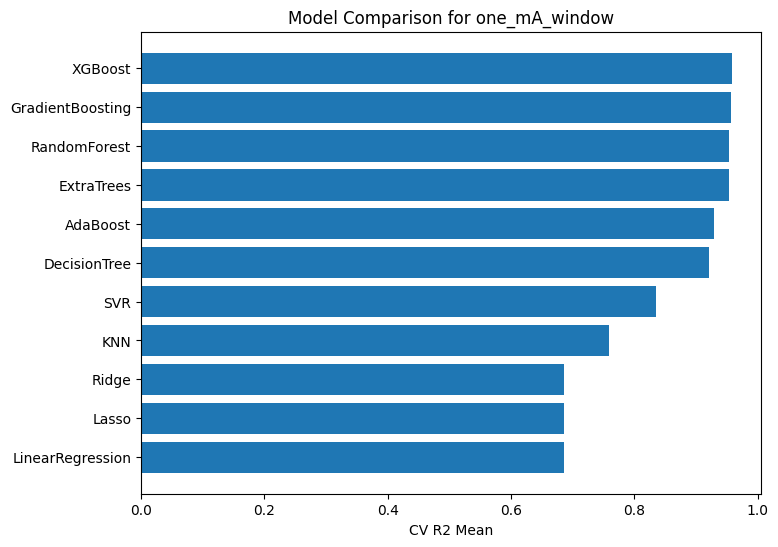

In [54]:
# 结果可视化 每个目标的模型对比图
for target_col in target_list:
    plot_df = (
        df_all_cv_results[df_all_cv_results["target"] == target_col]
        .sort_values("CV_R2_mean", ascending=True)
    )
    
    plt.figure(figsize=(8, 6))
    plt.barh(plot_df["model"], plot_df["CV_R2_mean"])
    plt.xlabel("CV R2 Mean")
    plt.title(f"Model Comparison for {target_col}")
    plt.show()

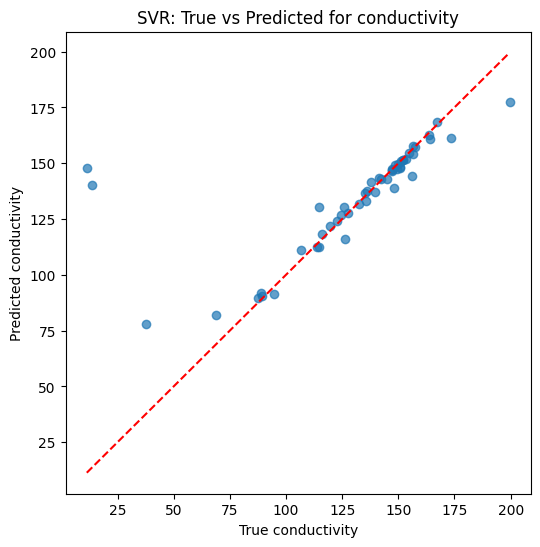

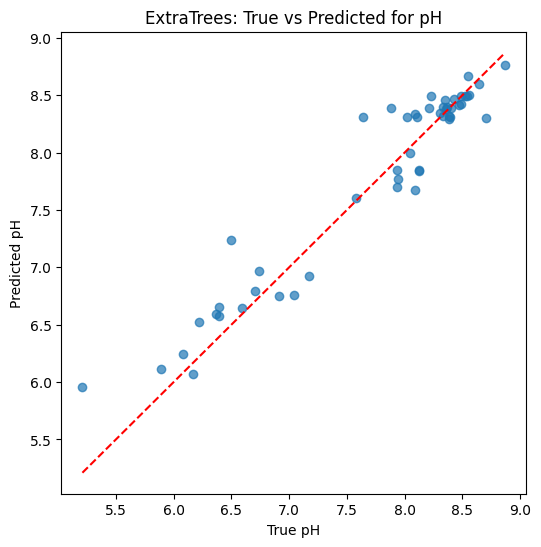

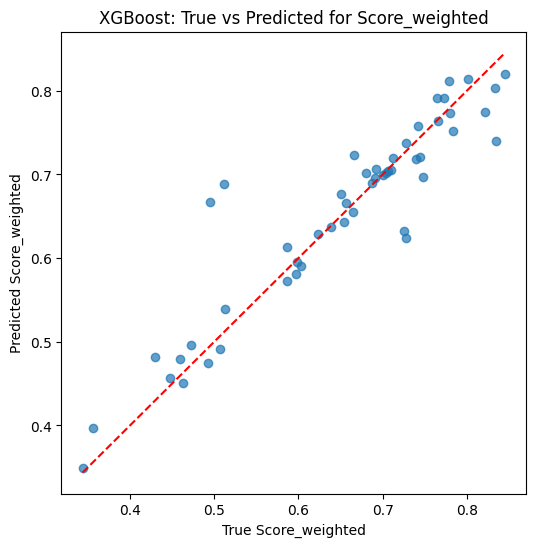

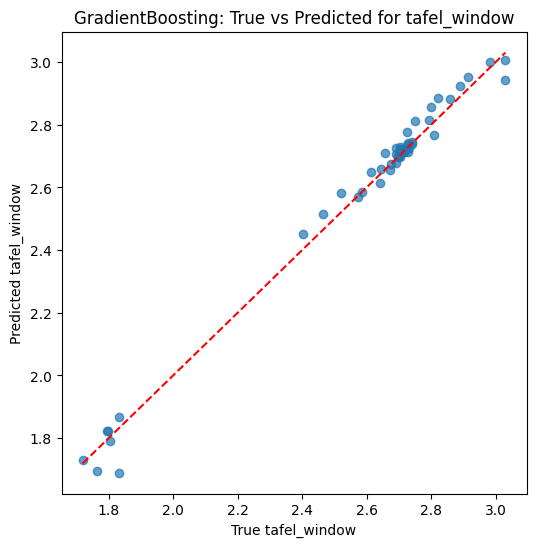

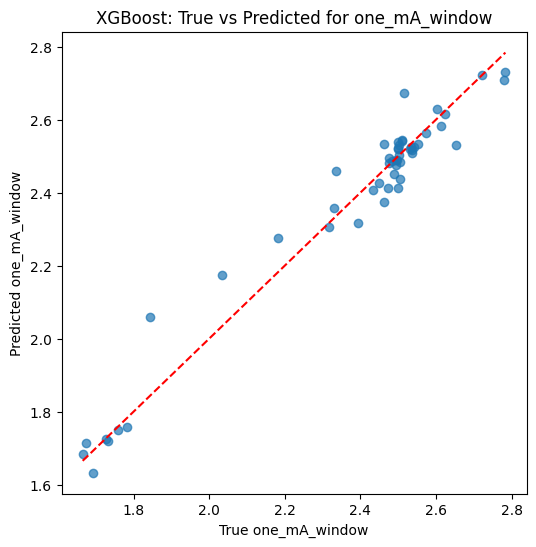

In [55]:
# 最佳模型真实值 vs 预测值图
for target_col in target_list:
    df_pred = saved_predictions[target_col]
    best_name = df_best_model_summary[df_best_model_summary["target"] == target_col]["best_cv_model"].values[0]
    
    plt.figure(figsize=(6, 6))
    plt.scatter(df_pred["y_true"], df_pred["y_pred"], alpha=0.7)
    plt.plot(
        [df_pred["y_true"].min(), df_pred["y_true"].max()],
        [df_pred["y_true"].min(), df_pred["y_true"].max()],
        "r--"
    )
    plt.xlabel(f"True {target_col}")
    plt.ylabel(f"Predicted {target_col}")
    plt.title(f"{best_name}: True vs Predicted for {target_col}")
    plt.show()

conductivity 的最佳模型 SVR 不支持 feature_importances_

===== pH 的最佳模型：ExtraTrees =====


,feature,importance
4,frac_NaBr,0.377355
15,vol_NaBr,0.352023
8,non_water_total_volume,0.033197
19,water_fraction,0.028700
7,frac_water,0.028486
18,vol_water,0.028034
9,num_active_solutes,0.025530
3,frac_Na2SO4,0.020246
16,vol_NaClO4,0.019962
14,vol_Na2SO4,0.019812


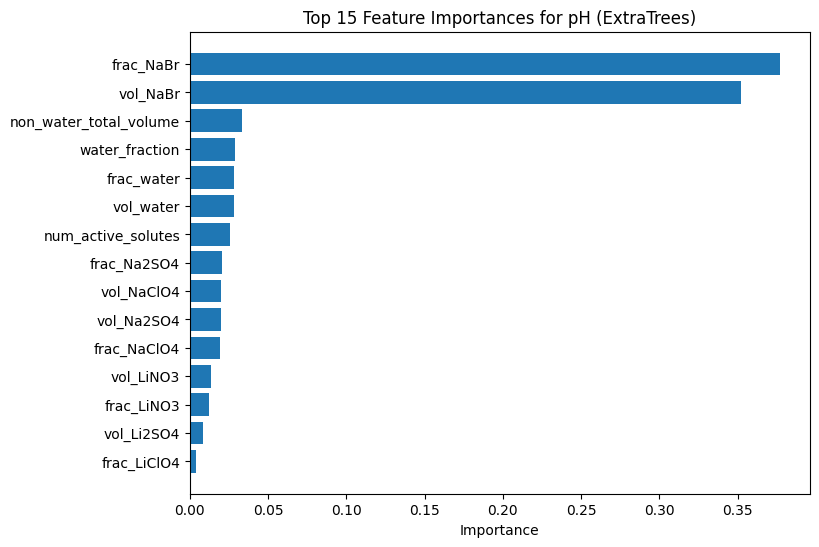


===== Score_weighted 的最佳模型：XGBoost =====


,feature,importance
4,frac_NaBr,0.540783
15,vol_NaBr,0.183515
19,water_fraction,0.109056
8,non_water_total_volume,0.042338
18,vol_water,0.037630
7,frac_water,0.020507
16,vol_NaClO4,0.012812
5,frac_NaClO4,0.010013
9,num_active_solutes,0.006055
14,vol_Na2SO4,0.005765


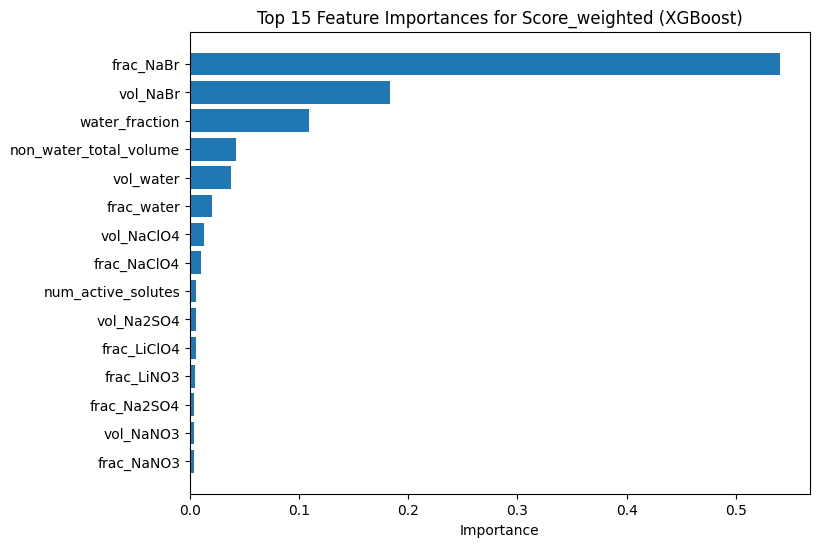


===== tafel_window 的最佳模型：GradientBoosting =====


,feature,importance
4,frac_NaBr,0.404098
15,vol_NaBr,0.404019
8,non_water_total_volume,0.039046
7,frac_water,0.036027
19,water_fraction,0.022619
16,vol_NaClO4,0.020940
18,vol_water,0.017860
5,frac_NaClO4,0.016490
2,frac_LiNO3,0.005741
6,frac_NaNO3,0.005314


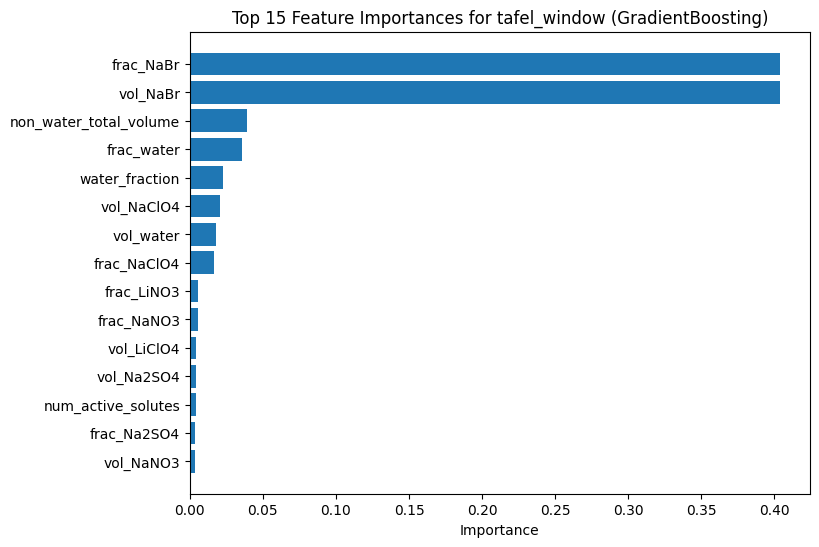


===== one_mA_window 的最佳模型：XGBoost =====


,feature,importance
4,frac_NaBr,0.540783
15,vol_NaBr,0.183515
19,water_fraction,0.109056
8,non_water_total_volume,0.042338
18,vol_water,0.037630
7,frac_water,0.020507
16,vol_NaClO4,0.012812
5,frac_NaClO4,0.010013
9,num_active_solutes,0.006055
14,vol_Na2SO4,0.005765


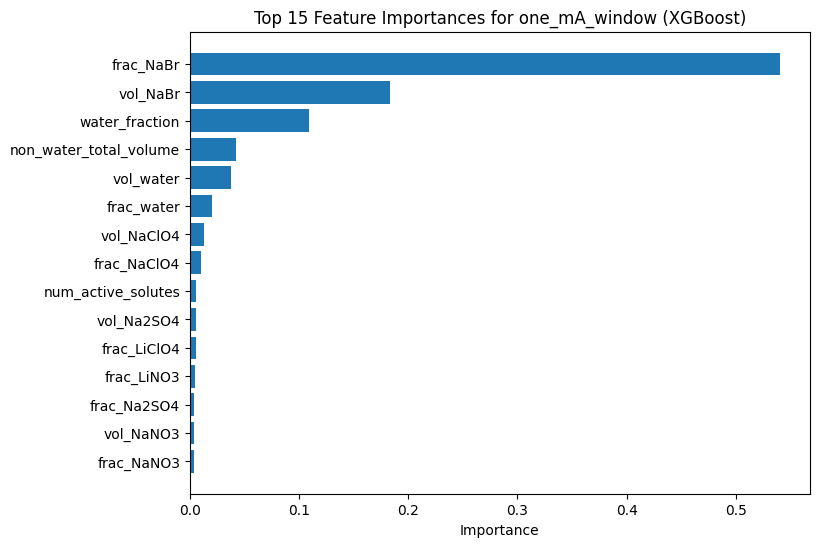

In [56]:
# 最佳模型特征重要性图
feature_importance_dict = {}

for target_col in target_list:
    best_name = df_best_model_summary[df_best_model_summary["target"] == target_col]["best_cv_model"].values[0]
    best_model = saved_models[target_col]
    fitted_model = best_model.named_steps["model"]
    
    if hasattr(fitted_model, "feature_importances_"):
        fi = pd.DataFrame({
            "feature": X_all.columns,
            "importance": fitted_model.feature_importances_
        }).sort_values("importance", ascending=False)
        
        feature_importance_dict[target_col] = fi
        
        print(f"\n===== {target_col} 的最佳模型：{best_name} =====")
        display(fi.head(15))
        
        fi_plot = fi.head(15).sort_values("importance")
        
        plt.figure(figsize=(8, 6))
        plt.barh(fi_plot["feature"], fi_plot["importance"])
        plt.xlabel("Importance")
        plt.title(f"Top 15 Feature Importances for {target_col} ({best_name})")
        plt.show()
    else:
        print(f"{target_col} 的最佳模型 {best_name} 不支持 feature_importances_")

In [57]:
'''
分析不同性能目标上的适用性差异
'''

'\n分析不同性能目标上的适用性差异\n'

In [58]:
# 定义“高/中/低性能区”分析函数
def analyze_by_group(y_true, y_pred):
    df_result = pd.DataFrame({
        "y_true": y_true,
        "y_pred": y_pred
    })
    
    df_result["abs_error"] = np.abs(df_result["y_true"] - df_result["y_pred"])
    df_result["error"] = df_result["y_pred"] - df_result["y_true"]
    
    q1 = df_result["y_true"].quantile(1/3)
    q2 = df_result["y_true"].quantile(2/3)
    
    def assign_group(x):
        if x <= q1:
            return "Low"
        elif x <= q2:
            return "Medium"
        else:
            return "High"
    
    df_result["group"] = df_result["y_true"].apply(assign_group)
    
    def calc_metrics(df_group):
        rmse = np.sqrt(mean_squared_error(df_group["y_true"], df_group["y_pred"]))
        mae = mean_absolute_error(df_group["y_true"], df_group["y_pred"])
        r2 = r2_score(df_group["y_true"], df_group["y_pred"])
        
        return pd.Series({
            "n_samples": len(df_group),
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2,
            "Mean_True": df_group["y_true"].mean(),
            "Mean_Pred": df_group["y_pred"].mean(),
            "Mean_Abs_Error": df_group["abs_error"].mean()
        })
    
    df_group_metrics = df_result.groupby("group").apply(calc_metrics).reset_index()
    
    order = ["Low", "Medium", "High"]
    df_group_metrics["group"] = pd.Categorical(df_group_metrics["group"], categories=order, ordered=True)
    df_group_metrics = df_group_metrics.sort_values("group")
    
    return df_result, df_group_metrics

In [59]:
# 对每个目标都做区间分析
group_analysis_results = {}

for target_col in target_list:
    y_test = saved_splits[target_col]["y_test"].values
    y_pred = saved_predictions[target_col]["y_pred"].values
    
    df_result, df_group_metrics = analyze_by_group(y_test, y_pred)
    group_analysis_results[target_col] = {
        "detail": df_result,
        "metrics": df_group_metrics
    }
    
    print(f"\n===== {target_col} 的分区表现 =====")
    display(df_group_metrics)


===== conductivity 的分区表现 =====


C:\Users\Percented\AppData\Local\Temp\ipykernel_19272\3817152306.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_group_metrics = df_result.groupby("group").apply(calc_metrics).reset_index()


,group,n_samples,RMSE,MAE,R2,Mean_True,Mean_Pred,Mean_Abs_Error
1,Low,17.0,46.494858,21.233201,-0.640906,91.235294,111.745912,21.233201
2,Medium,17.0,3.725180,2.363615,0.731109,140.388235,139.222219,2.363615
0,High,17.0,6.954495,3.793340,0.658532,159.429412,155.923881,3.793340



===== pH 的分区表现 =====


C:\Users\Percented\AppData\Local\Temp\ipykernel_19272\3817152306.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_group_metrics = df_result.groupby("group").apply(calc_metrics).reset_index()


...

C:\Users\Percented\AppData\Local\Temp\ipykernel_19272\3817152306.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_group_metrics = df_result.groupby("group").apply(calc_metrics).reset_index()


,group,n_samples,RMSE,MAE,R2,Mean_True,Mean_Pred,Mean_Abs_Error
1,Low,17.0,0.049489,0.036924,0.984110,2.253856,2.259359,0.036924
2,Medium,17.0,0.018557,0.012948,-0.970547,2.703564,2.713007,0.012948
0,High,17.0,0.038668,0.030722,0.860045,2.827340,2.837751,0.030722



===== one_mA_window 的分区表现 =====


C:\Users\Percented\AppData\Local\Temp\ipykernel_19272\3817152306.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_group_metrics = df_result.groupby("group").apply(calc_metrics).reset_index()


,group,n_samples,RMSE,MAE,R2,Mean_True,Mean_Pred,Mean_Abs_Error
1,Low,17.0,0.081426,0.058624,0.932415,2.048118,2.067353,0.058624
2,Medium,17.0,0.039697,0.029982,-9.248189,2.491720,2.486094,0.029982
0,High,17.0,0.056553,0.038467,0.583454,2.595537,2.586749,0.038467


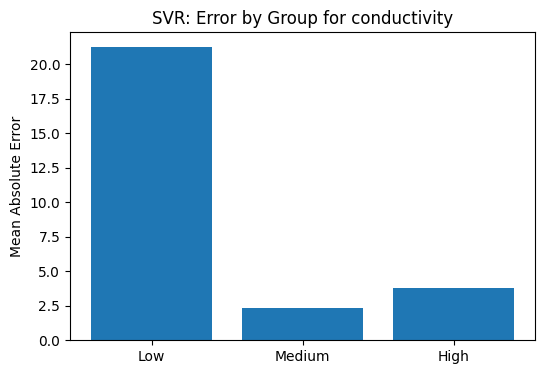

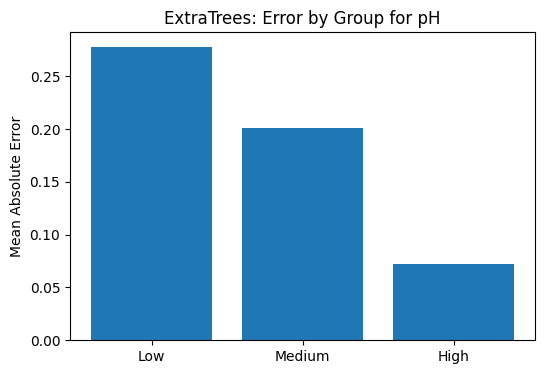

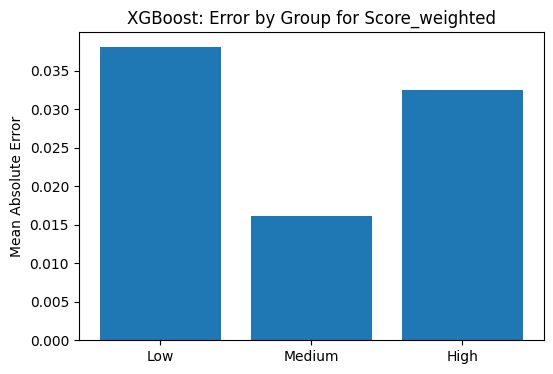

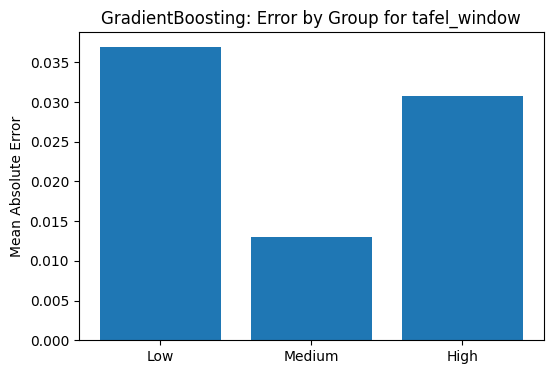

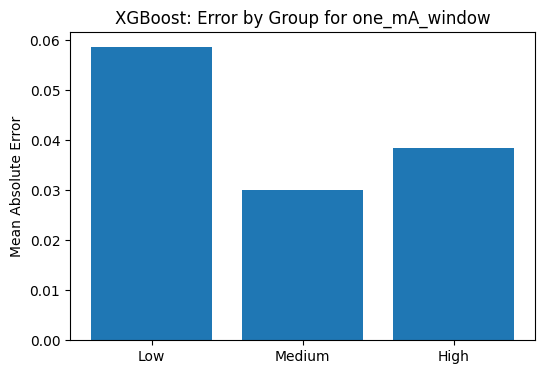

In [60]:
# 分区误差图
for target_col in target_list:
    df_group_metrics = group_analysis_results[target_col]["metrics"]
    best_name = df_best_model_summary[df_best_model_summary["target"] == target_col]["best_cv_model"].values[0]
    
    plt.figure(figsize=(6, 4))
    plt.bar(df_group_metrics["group"], df_group_metrics["Mean_Abs_Error"])
    plt.ylabel("Mean Absolute Error")
    plt.title(f"{best_name}: Error by Group for {target_col}")
    plt.show()

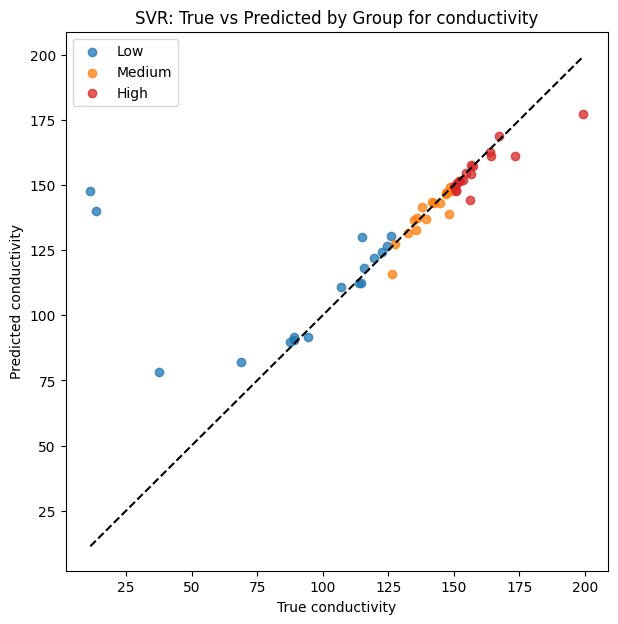

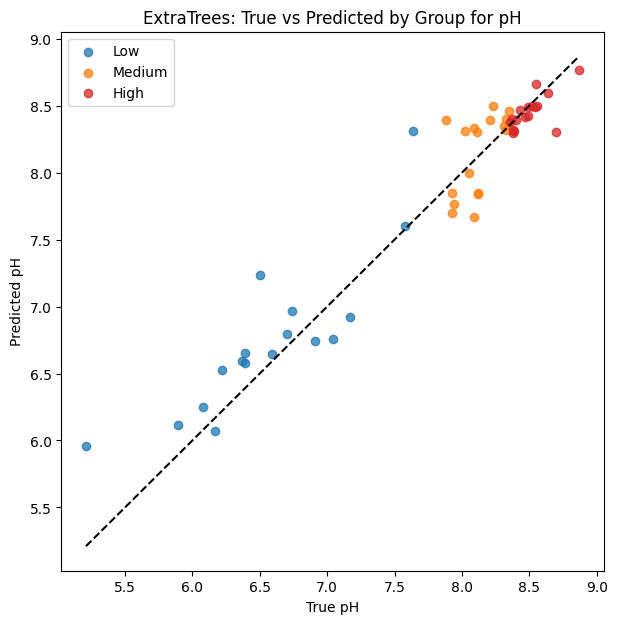

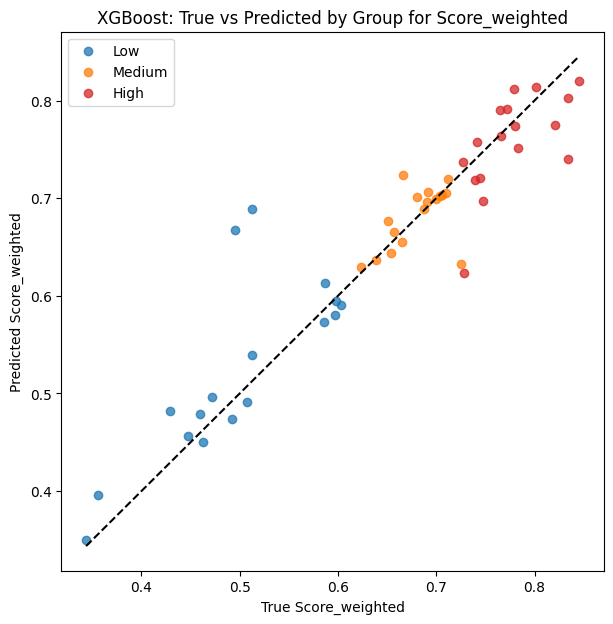

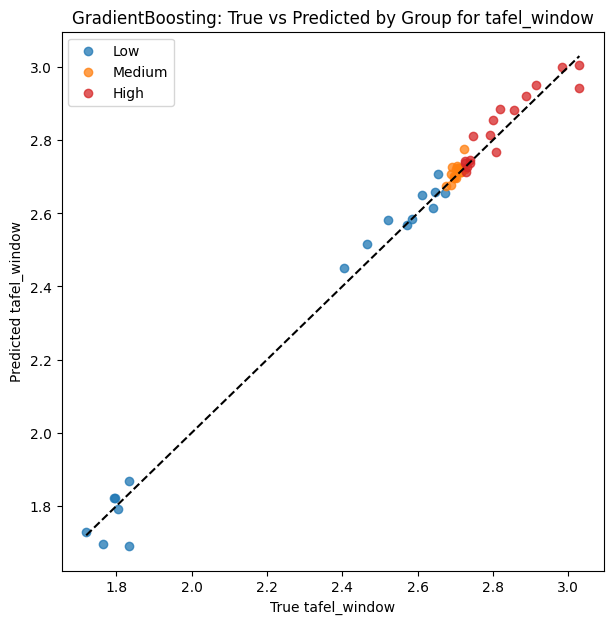

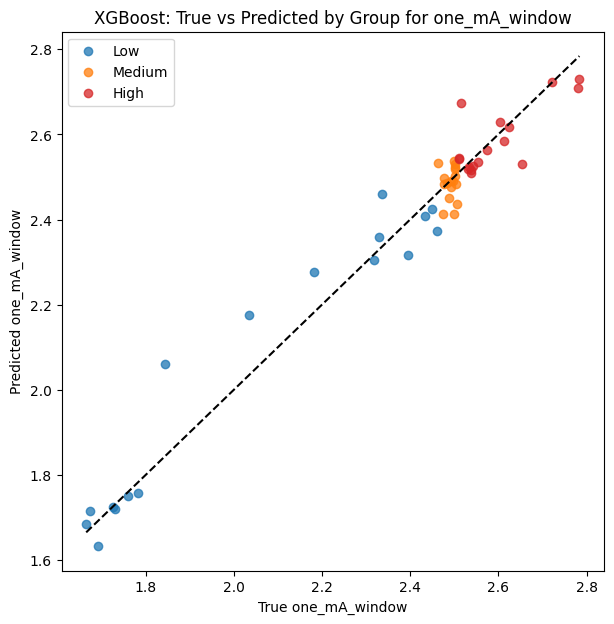

In [61]:
# 分区散点图
color_map = {"Low": "tab:blue", "Medium": "tab:orange", "High": "tab:red"}

for target_col in target_list:
    df_result = group_analysis_results[target_col]["detail"]
    best_name = df_best_model_summary[df_best_model_summary["target"] == target_col]["best_cv_model"].values[0]
    
    plt.figure(figsize=(7, 7))
    
    for group in ["Low", "Medium", "High"]:
        temp = df_result[df_result["group"] == group]
        plt.scatter(
            temp["y_true"],
            temp["y_pred"],
            alpha=0.75,
            label=group,
            color=color_map[group]
        )
    
    plt.plot(
        [df_result["y_true"].min(), df_result["y_true"].max()],
        [df_result["y_true"].min(), df_result["y_true"].max()],
        "k--"
    )
    
    plt.xlabel(f"True {target_col}")
    plt.ylabel(f"Predicted {target_col}")
    plt.title(f"{best_name}: True vs Predicted by Group for {target_col}")
    plt.legend()
    plt.show()

In [62]:
# 找特殊样本 误差最大的样本就是要分析的“特殊样本”
special_samples_dict = {}

for target_col in target_list:
    df_result = group_analysis_results[target_col]["detail"].copy()
    special_samples = df_result.sort_values("abs_error", ascending=False).head(10)
    special_samples_dict[target_col] = special_samples
    
    print(f"\n===== {target_col} 误差最大的10个特殊样本 =====")
    display(special_samples)


===== conductivity 误差最大的10个特殊样本 =====


,y_true,y_pred,abs_error,error,group
1,11.32,147.765236,136.445236,136.445236,Low
30,13.68,140.158467,126.478467,126.478467,Low
43,37.60,78.167207,40.567207,40.567207,Low
7,199.50,177.253321,22.246679,-22.246679,High
0,114.80,130.244841,15.444841,15.444841,Low
46,69.00,82.011454,13.011454,13.011454,Low
26,173.40,161.367518,12.032482,-12.032482,High
34,156.20,144.209443,11.990557,-11.990557,High
19,126.30,115.948370,10.351630,-10.351630,Medium
2,148.20,139.008642,9.191358,-9.191358,Medium



===== pH 误差最大的10个特殊样本 =====


,y_true,y_pred,abs_error,error,group
35,5.21,5.956191,0.746191,0.746191,Low
50,6.50,7.236940,0.736940,0.736940,Low
27,7.64,8.310038,0.670038,0.670038,Low
21,7.88,8.390508,0.510508,0.510508,Medium
17,8.09,7.671251,0.418749,-0.418749,Medium
20,8.70,8.304244,0.395756,-0.395756,High
9,6.22,6.526264,0.306264,0.306264,Low
8,8.02,8.309595,0.289595,0.289595,Medium
13,7.04,6.755286,0.284714,-0.284714,Low
31,8.12,7.837321,0.282679,-0.282679,Medium



===== Score_weighted 误差最大的10个特殊样本 =====


,y_true,y_pred,abs_error,error,group
1,0.512088,0.689067,0.176979,0.176979,Low
30,0.495527,0.667526,0.171999,0.171999,Low
45,0.727881,0.623789,0.104092,-0.104092,High
50,0.834035,0.739714,0.094321,-0.094321,High
8,0.725628,0.632816,0.092812,-0.092812,Medium
35,0.665896,0.723303,0.057407,0.057407,Medium
46,0.429409,0.481682,0.052273,0.052273,Low
27,0.747689,0.697234,0.050456,-0.050456,High
26,0.820911,0.774772,0.046140,-0.046140,High
0,0.355684,0.396473,0.040790,0.040790,Low



===== tafel_window 误差最大的10个特殊样本 =====


,y_true,y_pred,abs_error,error,group
38,1.832842,1.690158,0.142684,-0.142684,Low
50,3.029998,2.943806,0.086192,-0.086192,High
0,1.763152,1.696709,0.066443,-0.066443,Low
36,2.748281,2.812403,0.064122,0.064122,High
17,2.820206,2.884066,0.063860,0.063860,High
10,2.520258,2.582084,0.061826,0.061826,Low
45,2.800252,2.854843,0.054591,0.054591,High
14,2.655585,2.708694,0.053109,0.053109,Low
47,2.724336,2.776015,0.051679,0.051679,Medium
46,2.465465,2.516634,0.051169,0.051169,Low



===== one_mA_window 误差最大的10个特殊样本 =====


,y_true,y_pred,abs_error,error,group
43,1.843585,2.059707,0.216122,0.216122,Low
2,2.514408,2.674316,0.159908,0.159908,High
46,2.034808,2.174867,0.140059,0.140059,Low
35,2.335923,2.459918,0.123995,0.123995,Low
25,2.653092,2.531369,0.121723,-0.121723,High
10,2.182680,2.275914,0.093234,0.093234,Low
42,2.461994,2.373817,0.088177,-0.088177,Low
39,2.499654,2.413935,0.085719,-0.085719,Medium
19,2.394392,2.317460,0.076932,-0.076932,Low
50,2.781050,2.709188,0.071862,-0.071862,High


In [63]:
# 保存结果
df_all_test_results.to_csv("module5_all_test_results.csv", index=False, encoding="utf-8-sig")
df_all_cv_results.to_csv("module5_all_cv_results.csv", index=False, encoding="utf-8-sig")
df_best_model_summary.to_csv("module5_best_model_summary.csv", index=False, encoding="utf-8-sig")
df_model_average_rank.to_csv("module5_model_average_rank.csv", index=False, encoding="utf-8-sig")

for target_col in target_list:
    group_analysis_results[target_col]["detail"].to_csv(
        f"module5_detail_{target_col}.csv", index=False, encoding="utf-8-sig"
    )
    group_analysis_results[target_col]["metrics"].to_csv(
        f"module5_group_metrics_{target_col}.csv", index=False, encoding="utf-8-sig"
    )

print("模块5结果已全部保存。")

模块5结果已全部保存。


In [64]:
'''

第三问

'''

'\n\n第三问\n\n'

In [67]:
# 导入SHAP库
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [66]:
# 设置要解释的目标
target_list_shap = ["Score_weighted", "tafel_window", "one_mA_window"]
target_list_shap

['Score_weighted', 'tafel_window', 'one_mA_window']

In [68]:
# 先检查这三个目标对应的最佳模型
df_best_model_summary[df_best_model_summary["target"].isin(target_list_shap)]

,target,best_test_model,best_test_R2,best_cv_model,best_cv_R2
2,Score_weighted,GradientBoosting,0.86507,XGBoost,0.917952
3,tafel_window,XGBoost,0.989294,GradientBoosting,0.990023
4,one_mA_window,XGBoost,0.958531,XGBoost,0.95767


In [69]:
# 定义一个 SHAP 分析函数 对一个目标自动完成主要分析
def run_shap_analysis_for_target(target_col, top_n=15):
    print("=" * 70)
    print(f"当前目标: {target_col}")
    
    # 1. 找该目标最佳模型
    best_model_name = df_best_model_summary[
        df_best_model_summary["target"] == target_col
    ]["best_cv_model"].values[0]
    
    print("最佳模型:", best_model_name)
    
    best_pipeline = saved_models[target_col]
    X_train = saved_splits[target_col]["X_train"]
    X_test = saved_splits[target_col]["X_test"]
    y_test = saved_splits[target_col]["y_test"]
    
    fitted_model = best_pipeline.named_steps["model"]
    
    # 2. 构造 explainer
    explainer = shap.Explainer(fitted_model, X_train)
    shap_values = explainer(X_test)
    
    # 3. SHAP重要性表
    shap_importance = pd.DataFrame({
        "feature": X_test.columns,
        "mean_abs_shap": np.abs(shap_values.values).mean(axis=0)
    }).sort_values("mean_abs_shap", ascending=False)
    
    print("\nSHAP重要性前15：")
    display(shap_importance.head(top_n))
    
    # 4. 全局重要性图
    print("\n[1] SHAP bar 图")
    shap.plots.bar(shap_values, max_display=top_n)
    
    # 5. beeswarm图
    print("\n[2] SHAP beeswarm 图")
    shap.plots.beeswarm(shap_values, max_display=top_n)
    
    return {
        "target": target_col,
        "best_model_name": best_model_name,
        "pipeline": best_pipeline,
        "fitted_model": fitted_model,
        "X_train": X_train,
        "X_test": X_test,
        "y_test": y_test,
        "explainer": explainer,
        "shap_values": shap_values,
        "shap_importance": shap_importance
    }

当前目标: Score_weighted
最佳模型: XGBoost

SHAP重要性前15：


,feature,mean_abs_shap
4,frac_NaBr,0.168352
7,frac_water,0.049859
5,frac_NaClO4,0.034976
15,vol_NaBr,0.020028
2,frac_LiNO3,0.014921
8,non_water_total_volume,0.014586
3,frac_Na2SO4,0.010876
6,frac_NaNO3,0.009517
16,vol_NaClO4,0.007253
0,frac_Li2SO4,0.007088



[1] SHAP bar 图


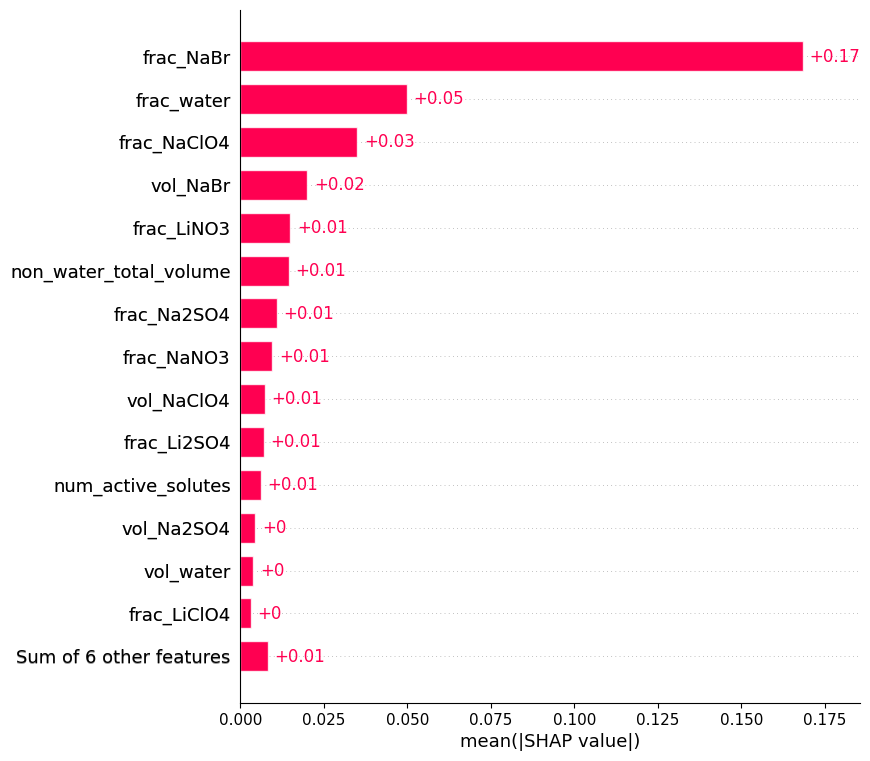


[2] SHAP beeswarm 图


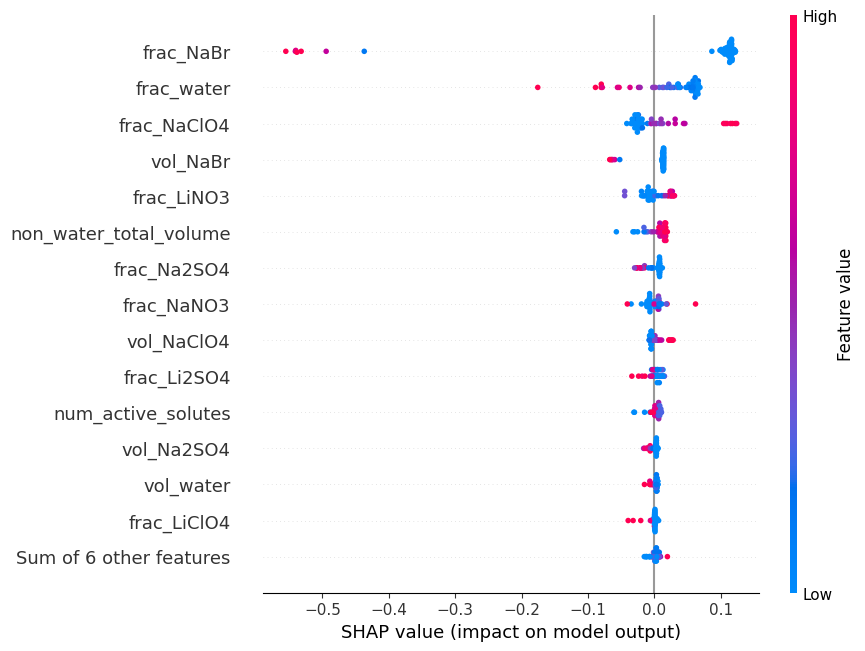

当前目标: tafel_window
最佳模型: GradientBoosting

SHAP重要性前15：


,feature,mean_abs_shap
4,frac_NaBr,0.098543
15,vol_NaBr,0.089488
8,non_water_total_volume,0.023779
16,vol_NaClO4,0.023332
7,frac_water,0.019921
19,water_fraction,0.015386
5,frac_NaClO4,0.014963
18,vol_water,0.010846
2,frac_LiNO3,0.009305
14,vol_Na2SO4,0.008704



[1] SHAP bar 图


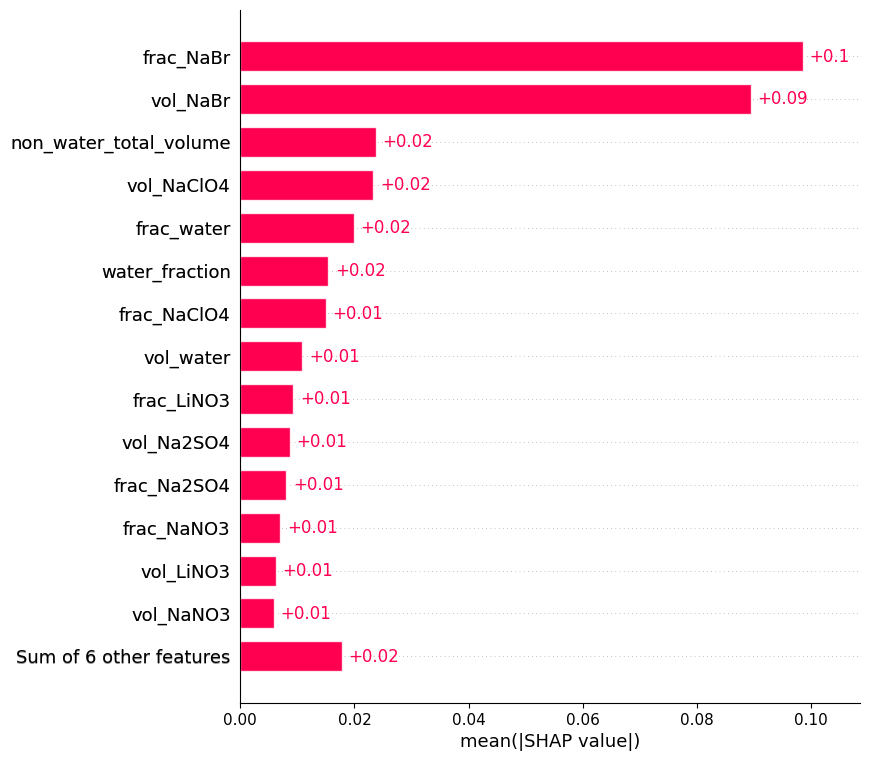


[2] SHAP beeswarm 图


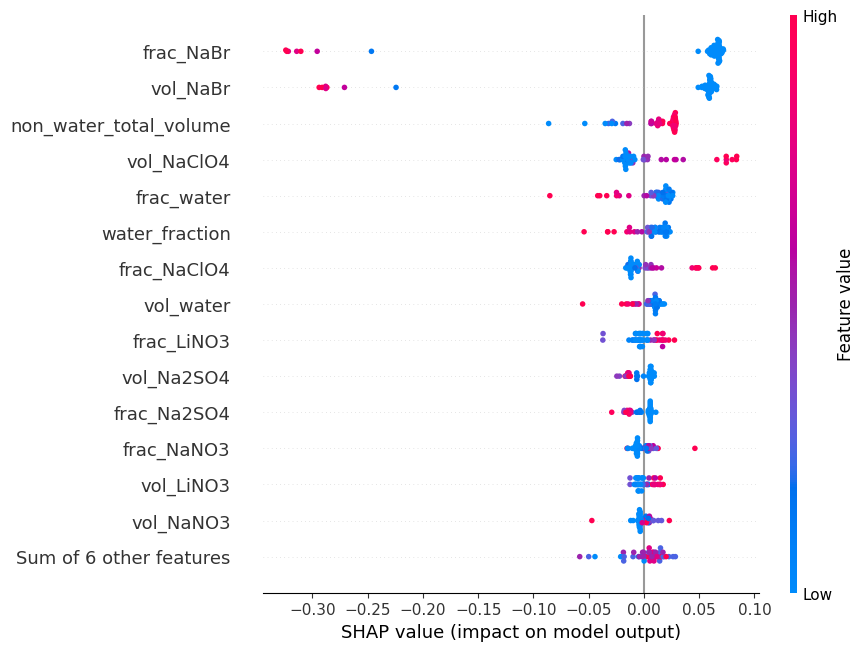

当前目标: one_mA_window
最佳模型: XGBoost

SHAP重要性前15：


,feature,mean_abs_shap
4,frac_NaBr,0.168352
7,frac_water,0.049859
5,frac_NaClO4,0.034976
15,vol_NaBr,0.020028
2,frac_LiNO3,0.014921
8,non_water_total_volume,0.014586
3,frac_Na2SO4,0.010876
6,frac_NaNO3,0.009517
16,vol_NaClO4,0.007253
0,frac_Li2SO4,0.007088



[1] SHAP bar 图


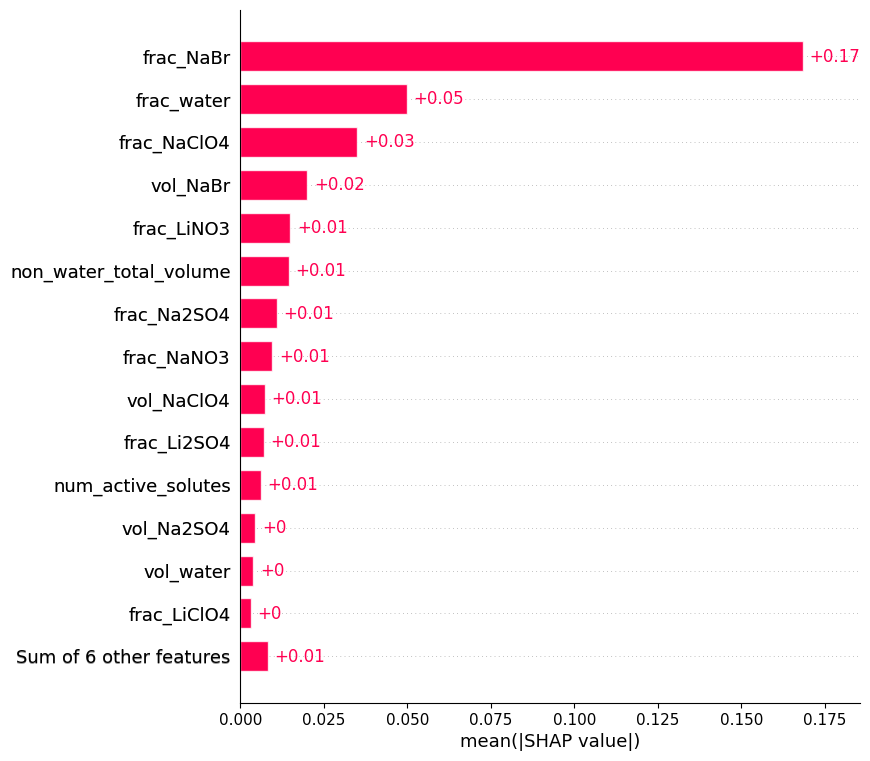


[2] SHAP beeswarm 图


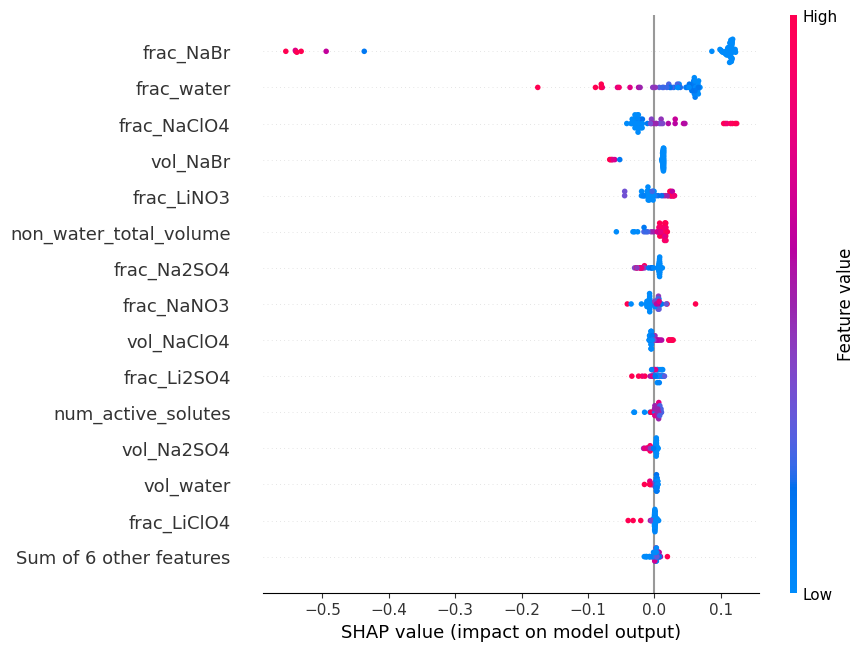

In [70]:
# 对三个目标分别运行 SHAP
shap_results = {}

for target_col in target_list_shap:
    shap_results[target_col] = run_shap_analysis_for_target(target_col, top_n=15)

In [ ]:
# 分别提取三个目标的重要性表

In [71]:
shap_results["Score_weighted"]["shap_importance"].head(15)

,feature,mean_abs_shap
4,frac_NaBr,0.168352
7,frac_water,0.049859
5,frac_NaClO4,0.034976
15,vol_NaBr,0.020028
2,frac_LiNO3,0.014921
8,non_water_total_volume,0.014586
3,frac_Na2SO4,0.010876
6,frac_NaNO3,0.009517
16,vol_NaClO4,0.007253
0,frac_Li2SO4,0.007088


In [73]:
shap_results["tafel_window"]["shap_importance"].head(15)

,feature,mean_abs_shap
4,frac_NaBr,0.098543
15,vol_NaBr,0.089488
8,non_water_total_volume,0.023779
16,vol_NaClO4,0.023332
7,frac_water,0.019921
19,water_fraction,0.015386
5,frac_NaClO4,0.014963
18,vol_water,0.010846
2,frac_LiNO3,0.009305
14,vol_Na2SO4,0.008704


In [75]:
shap_results["one_mA_window"]["shap_importance"].head(15)

,feature,mean_abs_shap
4,frac_NaBr,0.168352
7,frac_water,0.049859
5,frac_NaClO4,0.034976
15,vol_NaBr,0.020028
2,frac_LiNO3,0.014921
8,non_water_total_volume,0.014586
3,frac_Na2SO4,0.010876
6,frac_NaNO3,0.009517
16,vol_NaClO4,0.007253
0,frac_Li2SO4,0.007088


In [ ]:
# 方向性分析：看关键特征到底是正向还是负向

In [77]:
# 定义一个 dependence 图函数
def plot_top_dependence(target_col, n_features=5):
    result = shap_results[target_col]
    shap_values = result["shap_values"]
    shap_importance = result["shap_importance"]
    
    top_features = shap_importance["feature"].head(n_features).tolist()
    
    print(f"\n===== {target_col} 的前{n_features}个特征 dependence 图 =====")
    print(top_features)
    
    for feat in top_features:
        print(f"\n特征: {feat}")
        shap.plots.scatter(shap_values[:, feat], color=shap_values)

In [ ]:
# 分别画三个目标的 dependence 图
'''
怎么读 dependence 图

如果某特征图表现为：

横轴越往右，SHAP 值越高

说明：

该特征增大时，会提升目标值

如果某特征图表现为：

横轴越往右，SHAP 值越低

说明：

该特征增大时，会压低目标值

如果图像是弯的、拐点明显

说明：

该特征对目标的影响是非线性的，可能存在阈值效应
'''


===== Score_weighted 的前5个特征 dependence 图 =====
['frac_NaBr', 'frac_water', 'frac_NaClO4', 'vol_NaBr', 'frac_LiNO3']

特征: frac_NaBr


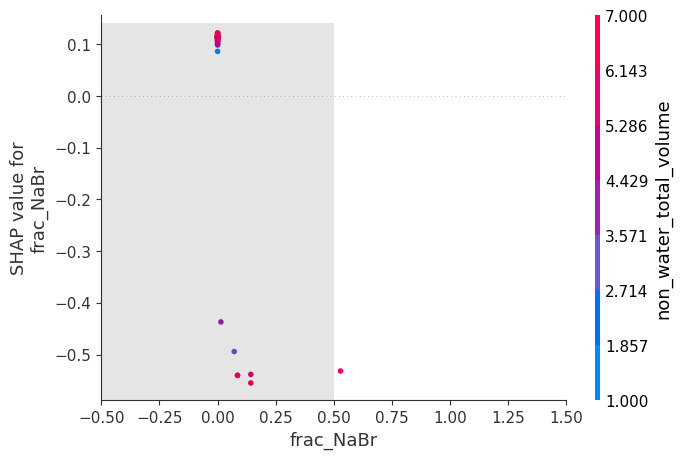


特征: frac_water


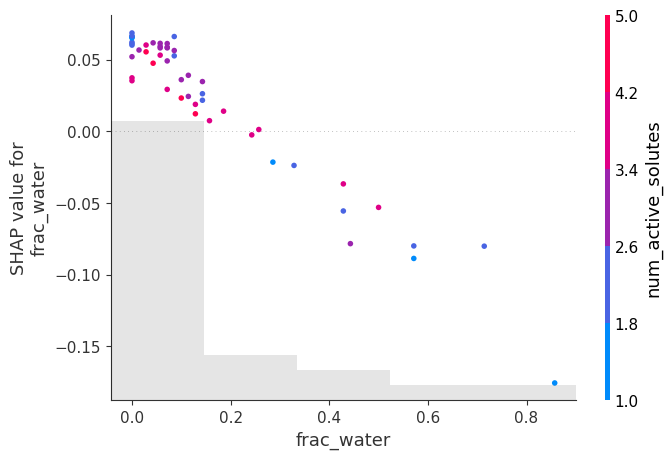


特征: frac_NaClO4


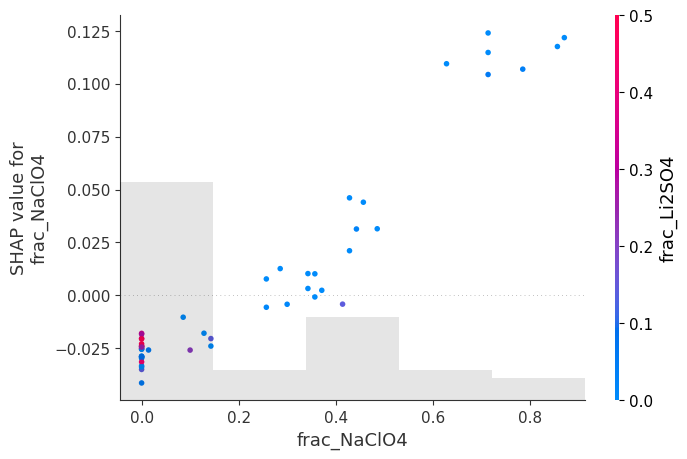


特征: vol_NaBr


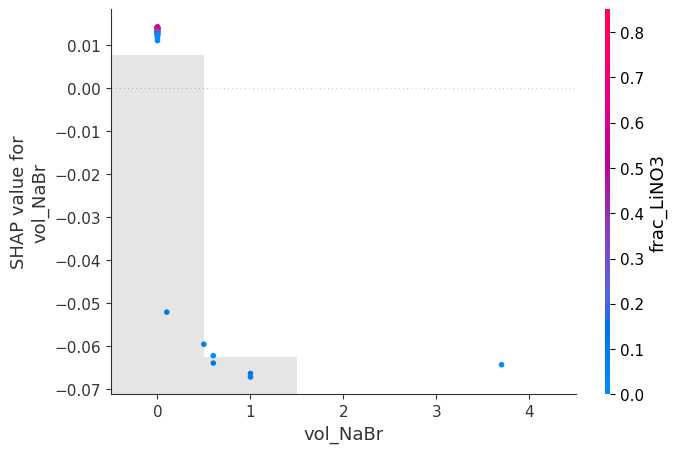


特征: frac_LiNO3


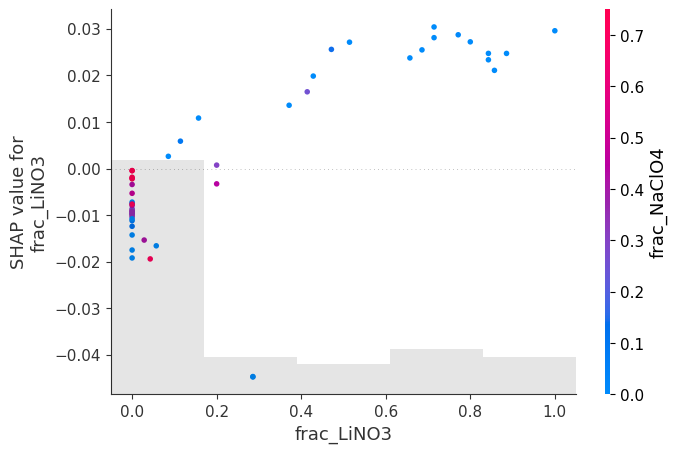

In [79]:
plot_top_dependence("Score_weighted", n_features=5)


===== tafel_window 的前5个特征 dependence 图 =====
['frac_NaBr', 'vol_NaBr', 'non_water_total_volume', 'vol_NaClO4', 'frac_water']

特征: frac_NaBr


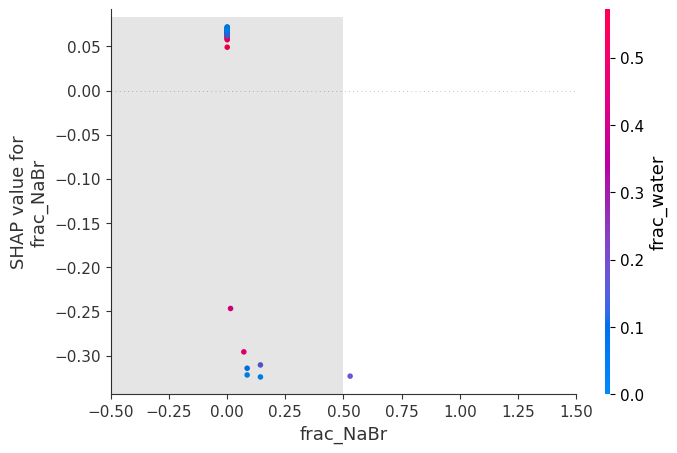


特征: vol_NaBr


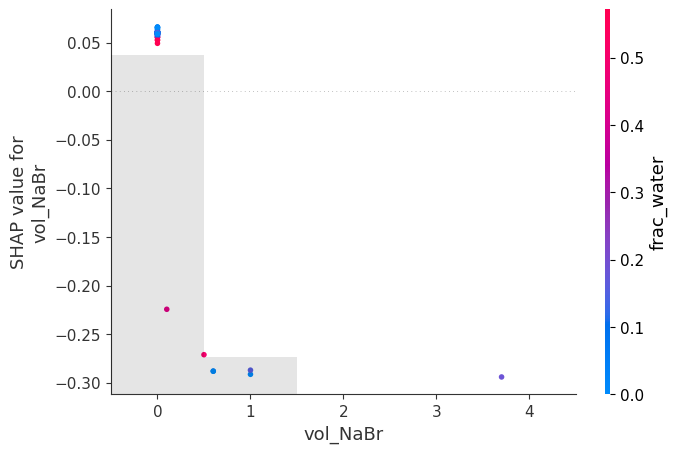


特征: non_water_total_volume


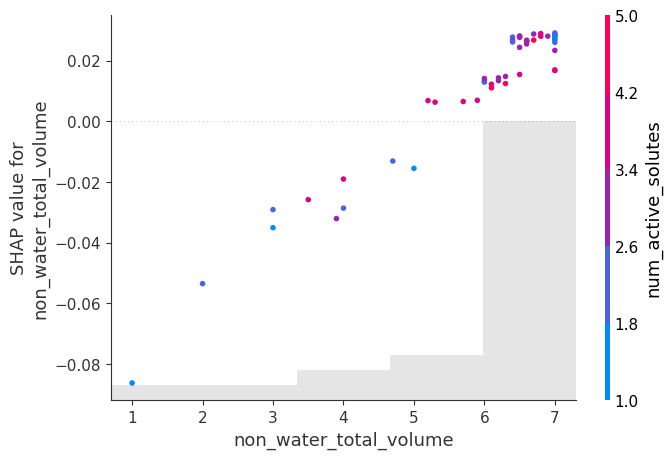


特征: vol_NaClO4


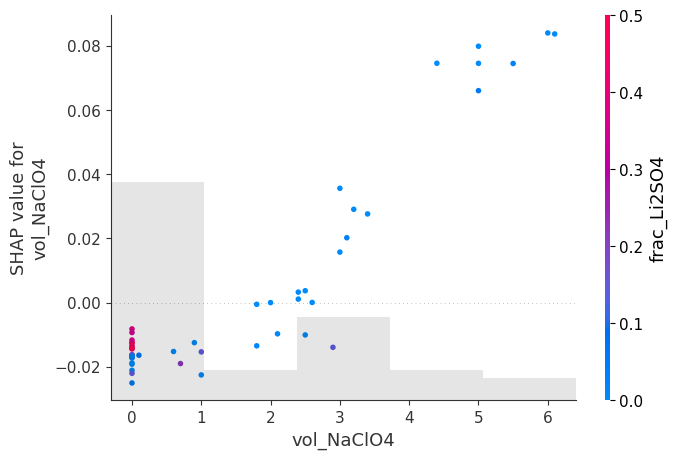


特征: frac_water


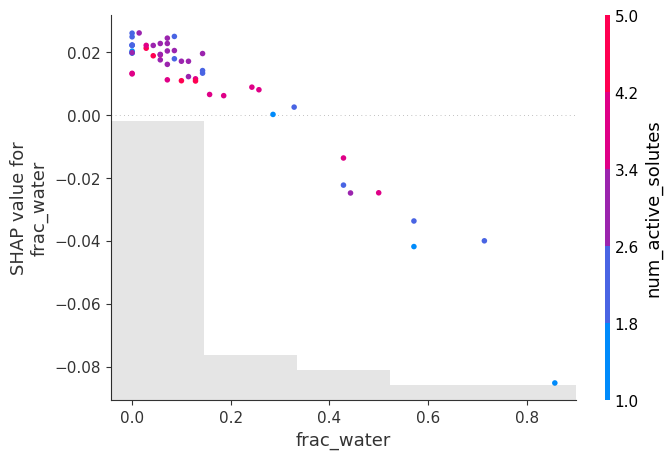

In [80]:
plot_top_dependence("tafel_window", n_features=5)


===== one_mA_window 的前5个特征 dependence 图 =====
['frac_NaBr', 'frac_water', 'frac_NaClO4', 'vol_NaBr', 'frac_LiNO3']

特征: frac_NaBr


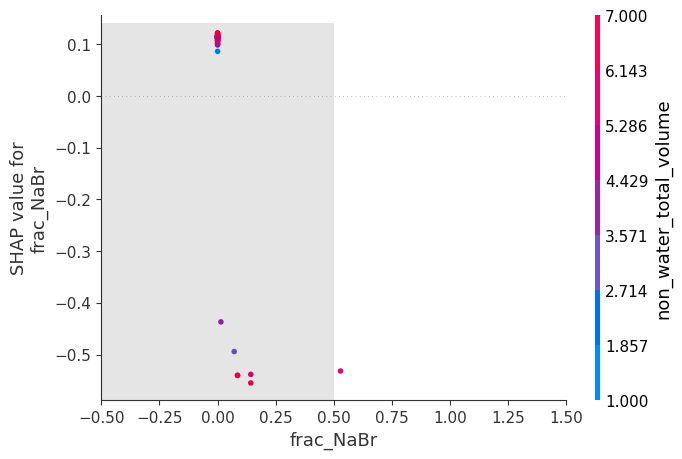


特征: frac_water


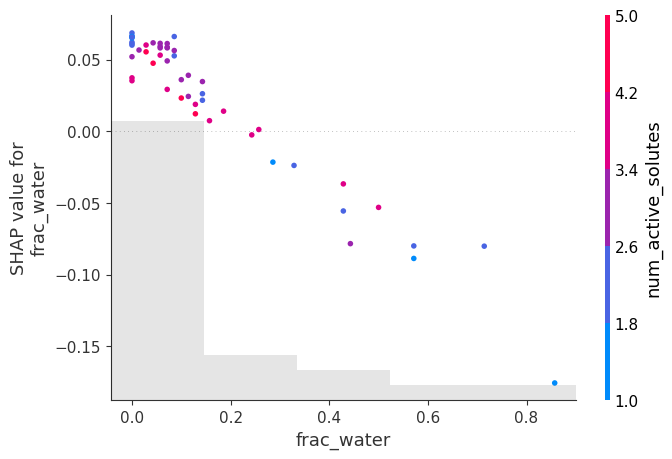


特征: frac_NaClO4


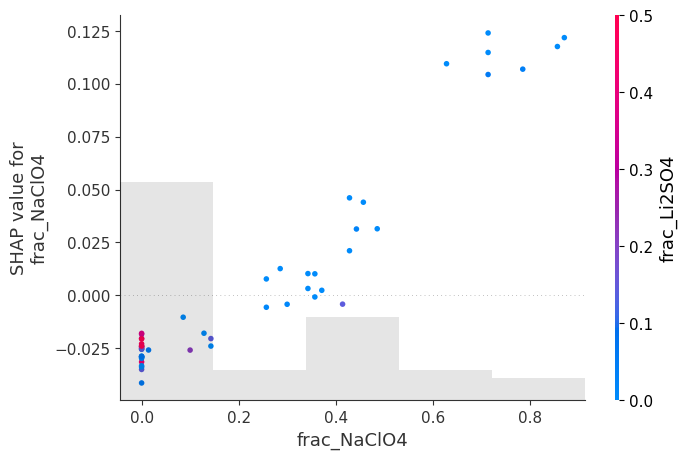


特征: vol_NaBr


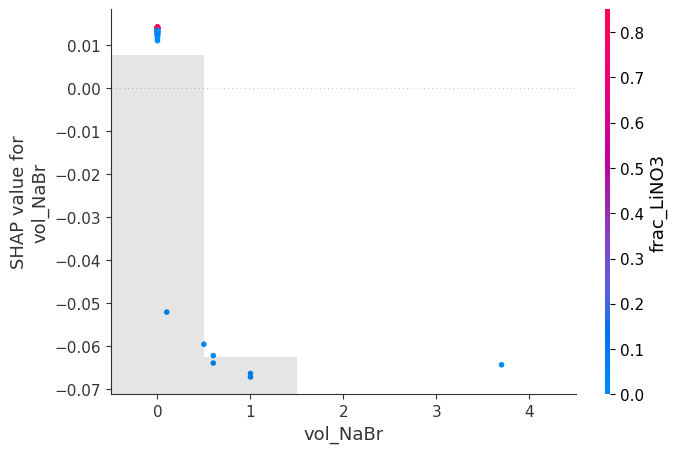


特征: frac_LiNO3


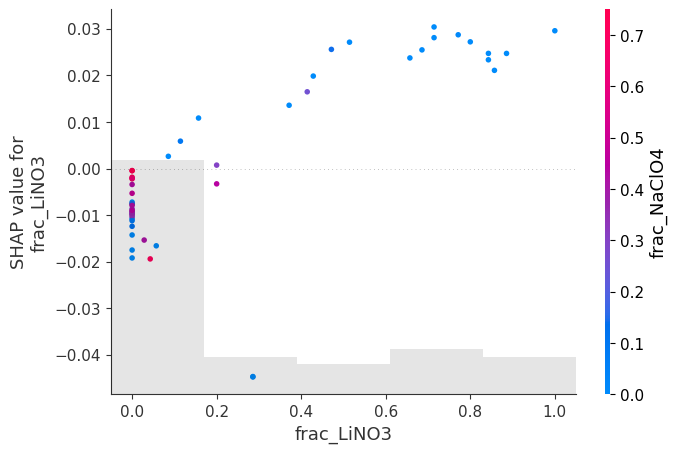

In [81]:
plot_top_dependence("one_mA_window", n_features=5)

In [ ]:
# 协同作用 / 交互作用分析

In [82]:
# 定义交互图函数
def plot_interaction(target_col, main_feature, color_feature):
    result = shap_results[target_col]
    shap_values = result["shap_values"]
    
    print(f"\n目标: {target_col}")
    print(f"主特征: {main_feature}")
    print(f"着色特征: {color_feature}")
    
    shap.plots.scatter(
        shap_values[:, main_feature],
        color=shap_values[:, color_feature]
    )


目标: Score_weighted
主特征: frac_NaBr
着色特征: water_fraction


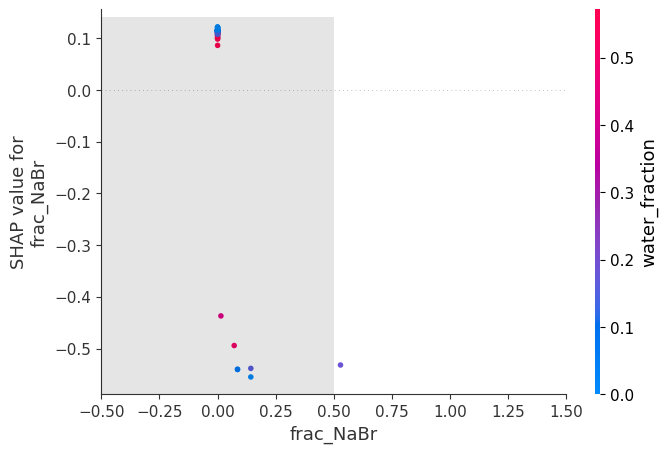


目标: Score_weighted
主特征: vol_NaBr
着色特征: frac_NaClO4


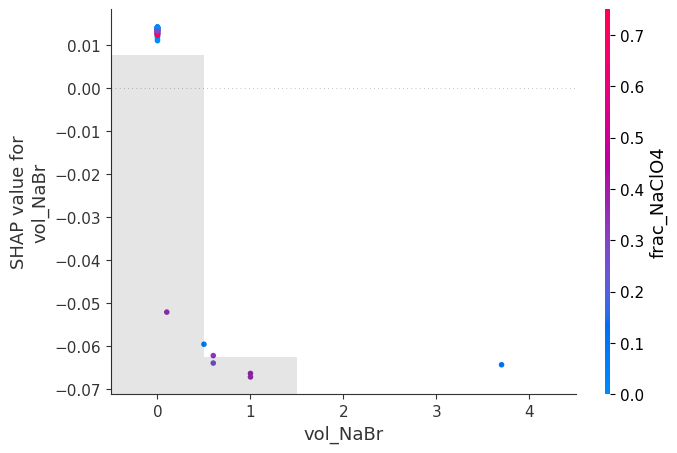

In [83]:
# 对综合评分 Score
plot_interaction("Score_weighted", "frac_NaBr", "water_fraction")
plot_interaction("Score_weighted", "vol_NaBr", "frac_NaClO4")


目标: tafel_window
主特征: frac_NaBr
着色特征: water_fraction


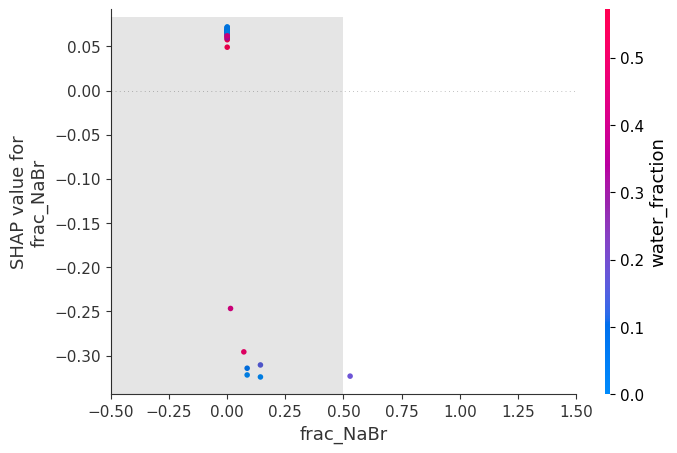


目标: tafel_window
主特征: vol_NaClO4
着色特征: frac_water


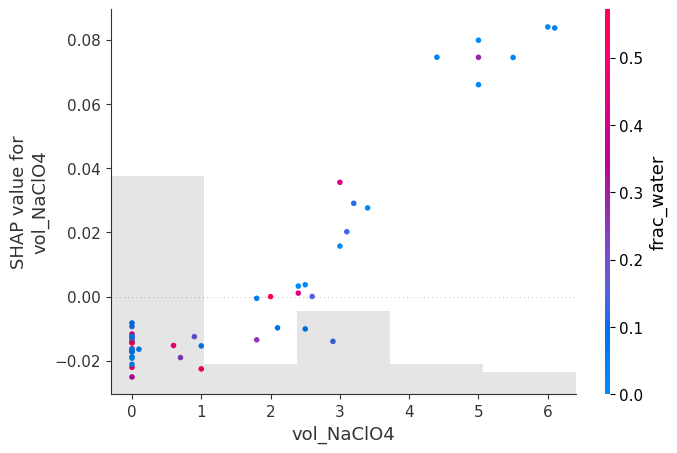

In [84]:
# 对Tafel 窗口
plot_interaction("tafel_window", "frac_NaBr", "water_fraction")
plot_interaction("tafel_window", "vol_NaClO4", "frac_water")


目标: one_mA_window
主特征: frac_NaBr
着色特征: water_fraction


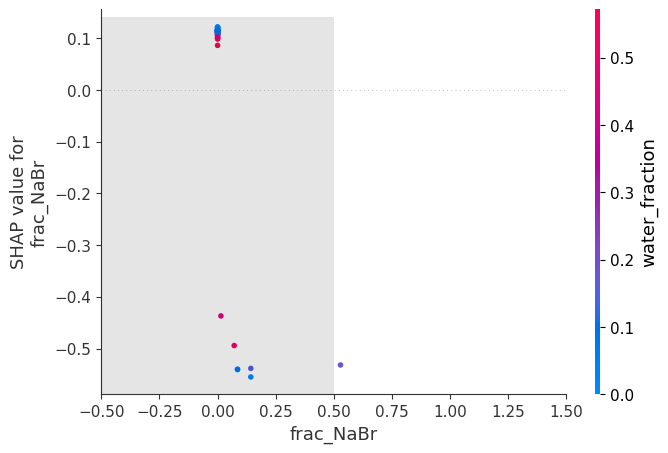


目标: one_mA_window
主特征: vol_NaClO4
着色特征: frac_NaBr


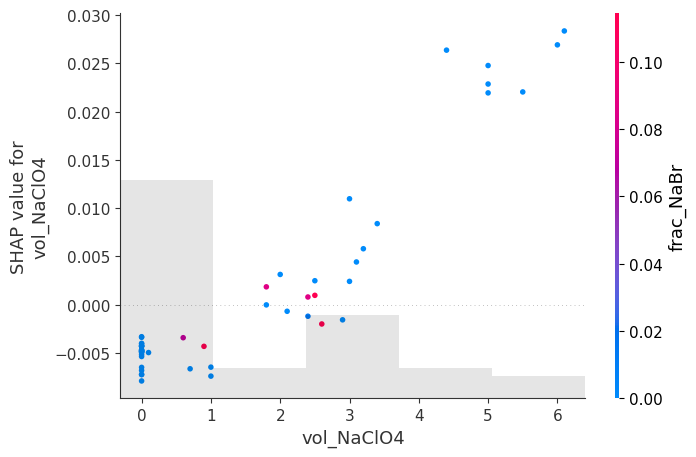

In [85]:
# 对1 mA 窗口
plot_interaction("one_mA_window", "frac_NaBr", "water_fraction")
plot_interaction("one_mA_window", "vol_NaClO4", "frac_NaBr")

In [ ]:
# 解释高分样本和低分样本

In [86]:
# 定义 waterfall 分析函数
def explain_extreme_samples(target_col, max_display=12):
    result = shap_results[target_col]
    X_test = result["X_test"]
    y_test = result["y_test"]
    shap_values = result["shap_values"]
    pipeline = result["pipeline"]
    
    y_pred = pipeline.predict(X_test)
    
    df_pred = pd.DataFrame({
        "y_true": y_test.values,
        "y_pred": y_pred
    }, index=X_test.index)
    
    high_idx = df_pred.sort_values("y_true", ascending=False).index[0]
    low_idx = df_pred.sort_values("y_true", ascending=True).index[0]
    
    high_pos = list(X_test.index).index(high_idx)
    low_pos = list(X_test.index).index(low_idx)
    
    print("=" * 70)
    print(f"目标: {target_col}")
    print("高值样本索引:", high_idx)
    print("低值样本索引:", low_idx)
    
    print("\n[高值样本 waterfall]")
    shap.plots.waterfall(shap_values[high_pos], max_display=max_display)
    
    print("\n[低值样本 waterfall]")
    shap.plots.waterfall(shap_values[low_pos], max_display=max_display)
    
    return df_pred, high_idx, low_idx

目标: Score_weighted
高值样本索引: 139
低值样本索引: 84

[高值样本 waterfall]


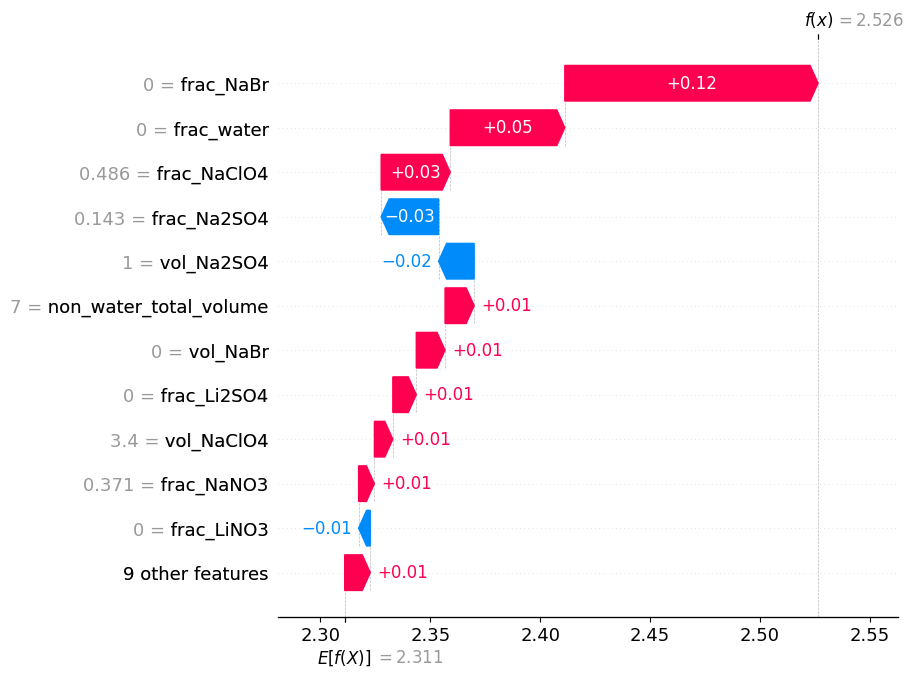


[低值样本 waterfall]


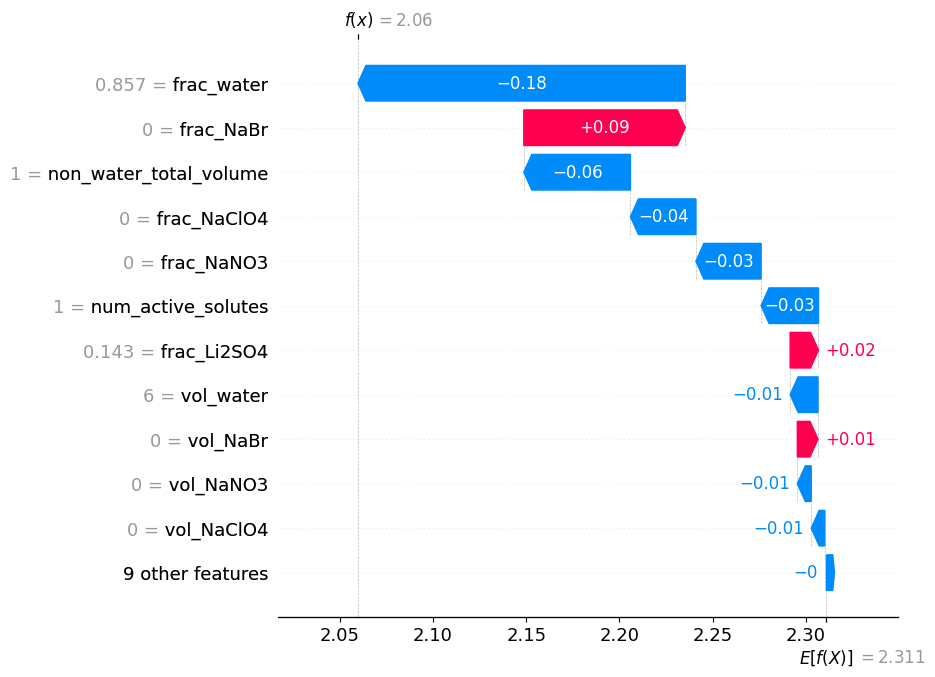

目标: tafel_window
高值样本索引: 173
低值样本索引: 248

[高值样本 waterfall]


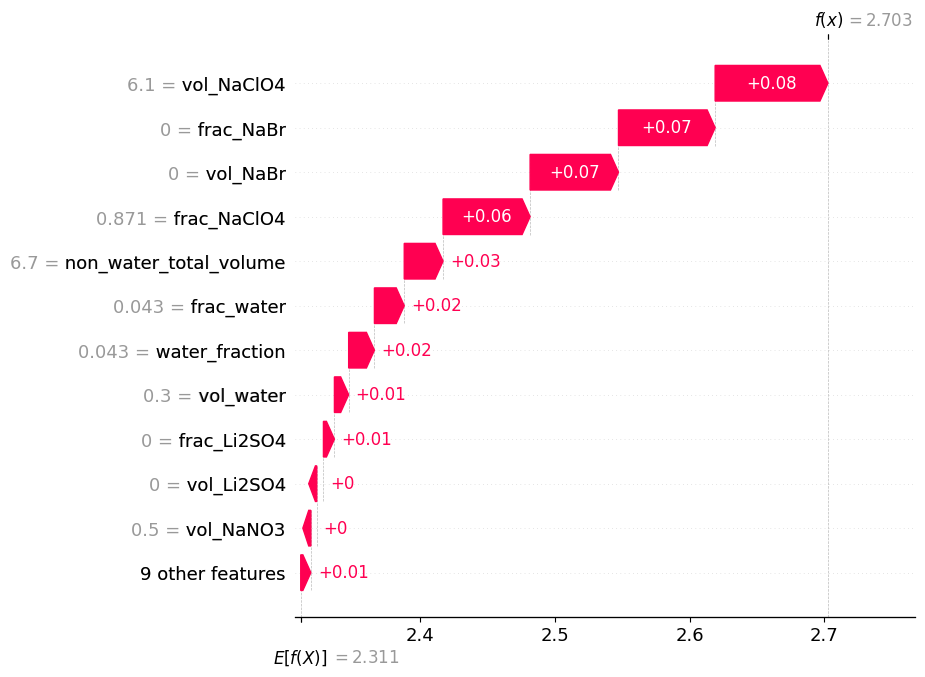


[低值样本 waterfall]


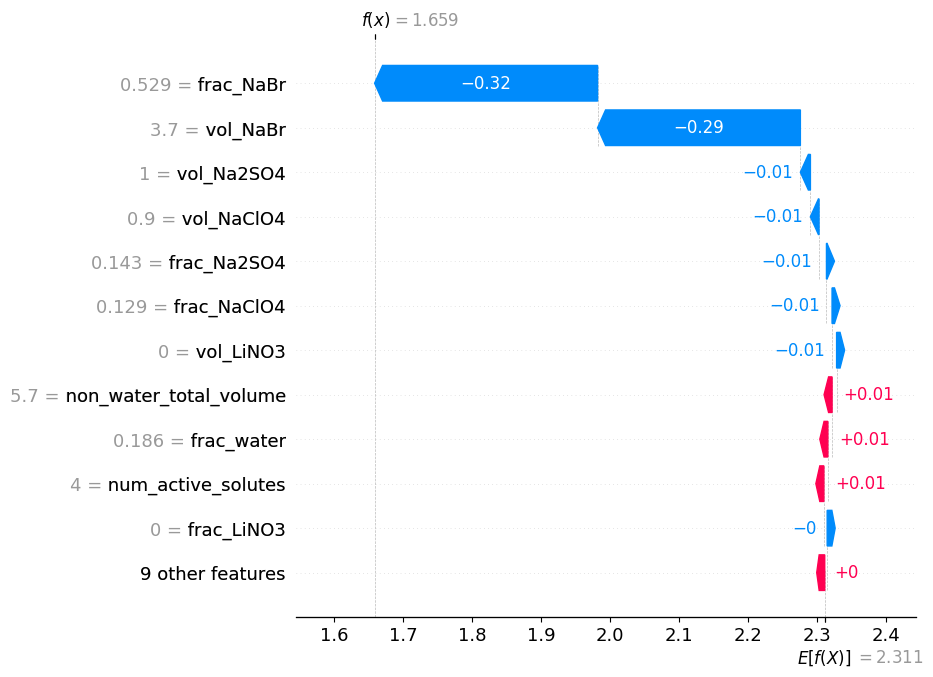

目标: one_mA_window
高值样本索引: 33
低值样本索引: 248

[高值样本 waterfall]


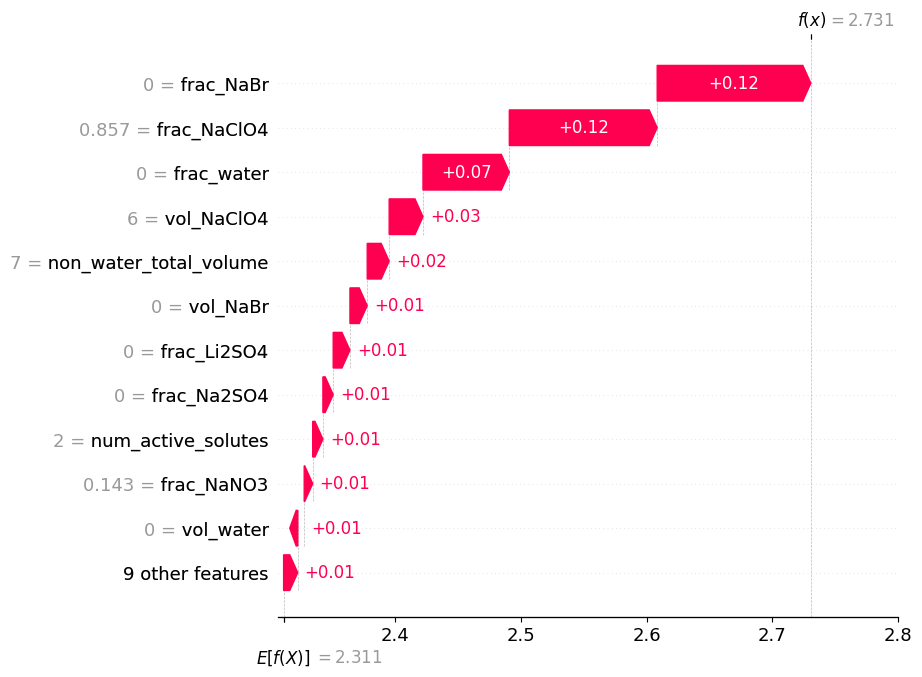


[低值样本 waterfall]


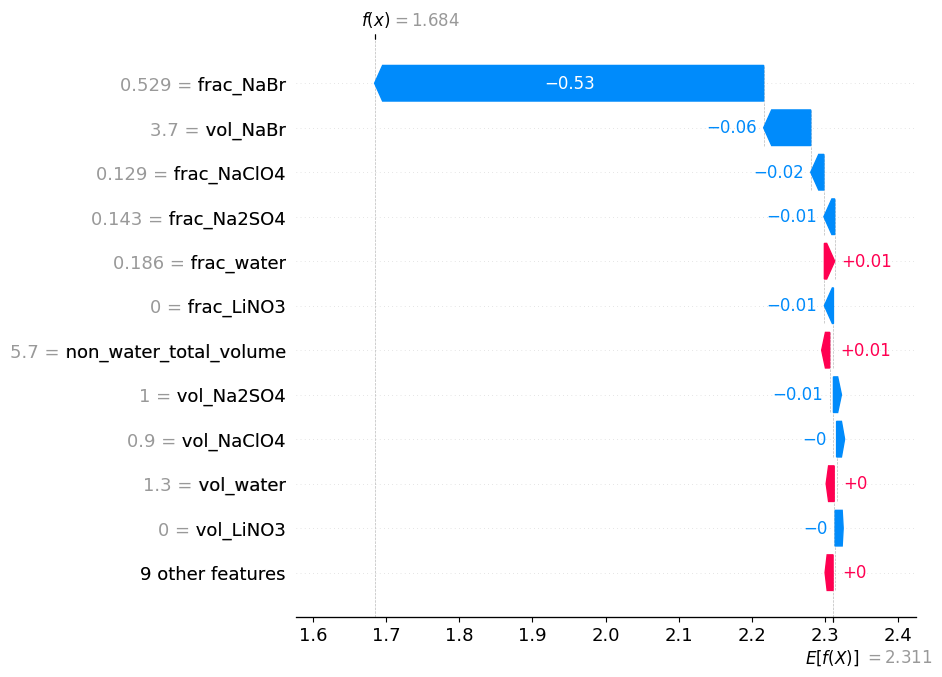

In [88]:
# 分别解释三个目标的高低样本
extreme_sample_results = {}

for target_col in target_list_shap:
    extreme_sample_results[target_col] = explain_extreme_samples(target_col, max_display=12)

In [89]:
# 保存三个目标的 SHAP 重要性表
for target_col in target_list_shap:
    shap_results[target_col]["shap_importance"].to_csv(
        f"shap_importance_{target_col}.csv",
        index=False,
        encoding="utf-8-sig"
    )

print("三个目标的 SHAP 重要性结果已保存。")

三个目标的 SHAP 重要性结果已保存。
